# Training Analysis — All Approaches

Training progression and evaluation for three spectral identification approaches: V1 encoder, V2 encoder, and reranker.

In [1]:
import json
import os
import re
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=0.95)
plt.rcParams.update({
    "figure.figsize": (6, 2),
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "svg.fonttype": "none",
})

LOGS_DIR = Path("../logs")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)
DATA_DIR = Path("../data")

%matplotlib inline

---
## Part 1 — V1 Spectral Graph Encoder

## 2. Key Design Decisions

- **Graph representation:** Peaks as nodes (6 features: log_mz, rel_intensity, sqrt_intensity, mz_ratio, neutral_loss, is_virtual) with fully-connected edges (25 features including neutral loss flags). Precursor as virtual node. Dense padded batching, no PyG dependency.
- **Multi-teacher training:** Joint optimization with ChemBERTa alignment (L_align x1.0), asymmetric contrastive loss (L_contrastive x0.2 -- noisy view retrieves clean anchor), and DreaMS distillation (L_distill x0.3, decaying to 0 at 60% of training).
- **Noise curriculum:** Mild/moderate for epochs 0-4, all four levels afterward. Matches expected real-world degradation.
- **Retrieval space fix:** Early runs retrieved in ChemBERTa's 768-dim molecular space (via mol_proj), which conflates spectral with molecular similarity. Fixed to spectrum-to-spectrum retrieval in the encoder's native 512-dim space -- mol_proj is now training-only auxiliary loss.

## 3. Training Curve Visualization

Load batch-level metrics from the JSONL log files and plot training curves.

In [2]:
def load_epoch_metrics(log_dir=LOGS_DIR, pattern="*"):
    """Load epoch-level metrics from the latest matching JSONL file."""
    paths = sorted(log_dir.glob(f"{pattern}_metrics.jsonl"))
    if not paths:
        print(f"No metrics files matching '{pattern}' in {log_dir}")
        return pd.DataFrame(), pd.DataFrame()
    p = paths[-1]
    rows = []
    with open(p) as f:
        for line in f:
            rows.append(json.loads(line))
    print(f"Loaded {p.name}: {len(rows)} entries")

    train_rows = [r for r in rows if "train/loss" in r]
    eval_rows = [r for r in rows if any(k.startswith("eval/") for k in r)]
    train_metrics = pd.DataFrame(train_rows)
    eval_metrics = pd.DataFrame(eval_rows)
    print(f"  Train epochs: {len(train_metrics)}, Eval epochs: {len(eval_metrics)}")
    return train_metrics, eval_metrics


def load_batch_metrics(log_dir=LOGS_DIR, pattern="*"):
    """Parse batch-level metrics from the latest matching .log file."""
    log_files = sorted(log_dir.glob(f"{pattern}.log"))
    if not log_files:
        print(f"No .log files matching '{pattern}' in {log_dir}")
        return pd.DataFrame()
    p = log_files[-1]
    pat = re.compile(r"\[step (\d+)\] (.+)")
    rows = []
    with open(p) as f:
        for line in f:
            m = pat.search(line)
            if not m:
                continue
            step = int(m.group(1))
            kvs = {"_step": step}
            for pair in m.group(2).split(" | "):
                k, v = pair.split("=")
                kvs[k.strip()] = float(v)
            rows.append(kvs)
    df = pd.DataFrame(rows)
    if len(df) > 0 and "batch/epoch" in df.columns:
        print(f"Loaded {p.name}: {len(df)} batch entries, epochs {df['batch/epoch'].min():.0f}-{df['batch/epoch'].max():.0f}")
    else:
        print(f"Loaded {p.name}: {len(df)} batch entries")
    return df


def load_config(log_dir=LOGS_DIR, pattern="*"):
    """Extract config dict from first line of latest matching .log file."""
    log_files = sorted(log_dir.glob(f"{pattern}.log"))
    if not log_files:
        return {}
    with open(log_files[-1]) as f:
        first_line = f.readline()
    if "Config:" in first_line:
        return json.loads(first_line.split("Config: ")[1])
    return {}


# Part 1: Load V1 encoder metrics
train_metrics, eval_metrics = load_epoch_metrics(pattern="custom_encoder_joint*")
batch_metrics = load_batch_metrics(pattern="custom_encoder_joint*")
config = load_config(pattern="custom_encoder_joint*")
print(f"\nConfig: {config.get('epochs')} epochs, batch_size={config.get('batch_size')}, "
      f"lr={config.get('lr')}, alpha={config.get('alpha')}, beta_0={config.get('beta_0')}, gamma={config.get('gamma')}")

Loaded custom_encoder_joint_20260226_144435_metrics.jsonl: 60 entries
  Train epochs: 30, Eval epochs: 30
Loaded custom_encoder_joint_20260226_144435.log: 645 batch entries, epochs 1-30

Config: 30 epochs, batch_size=2048, lr=0.0003, alpha=0.2, beta_0=0.3, gamma=0.1


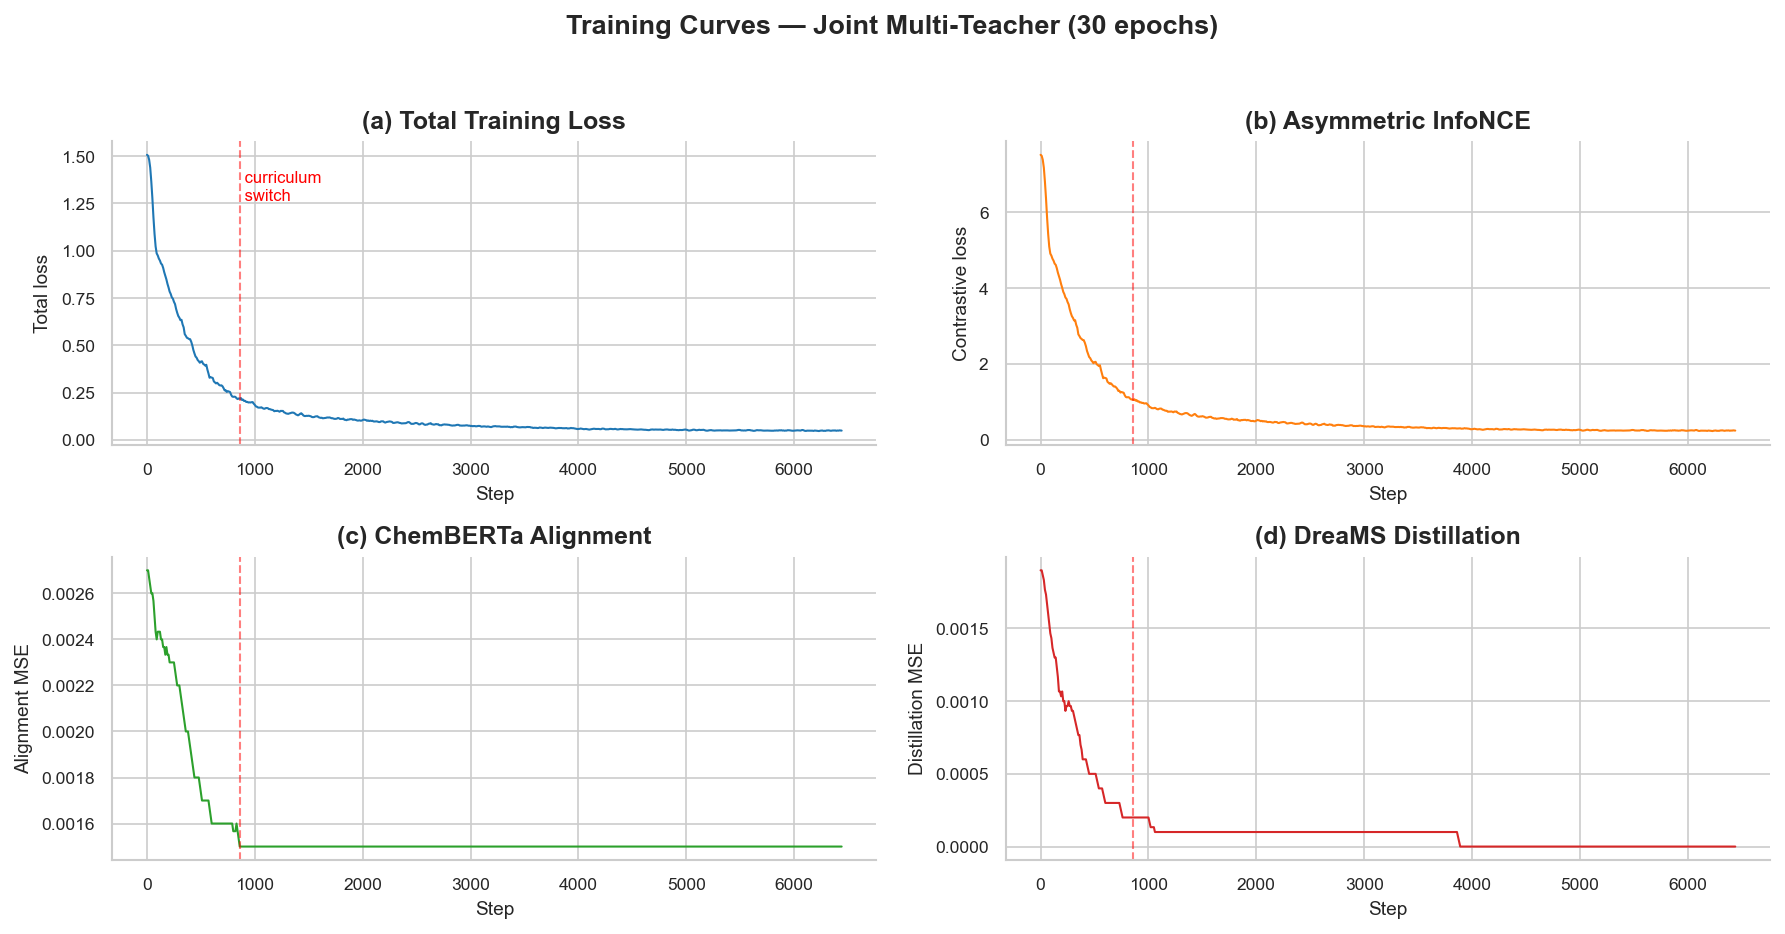

In [3]:
if len(batch_metrics) > 0:
    window = max(1, len(batch_metrics) // 200)

    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    axes = axes.flatten()

    plots = [
        ("batch/loss", "Total loss", "#1f77b4", "(a) Total Training Loss"),
        ("batch/contrastive", "Contrastive loss", "#ff7f0e", "(b) Asymmetric InfoNCE"),
        ("batch/align", "Alignment MSE", "#2ca02c", "(c) ChemBERTa Alignment"),
        ("batch/distill", "Distillation MSE", "#d62728", "(d) DreaMS Distillation"),
    ]

    for ax, (col, ylabel, color, title) in zip(axes, plots):
        smoothed = batch_metrics[col].rolling(window, min_periods=1).mean()
        ax.plot(batch_metrics["_step"], smoothed, color=color, linewidth=1)
        ax.set_xlabel("Step")
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight="bold")

    # Mark curriculum transition at epoch 5
    if batch_metrics["batch/epoch"].max() >= 5:
        transition_step = batch_metrics.loc[batch_metrics["batch/epoch"] >= 5, "_step"].iloc[0]
        for ax in axes:
            ax.axvline(transition_step, color="red", linestyle="--", alpha=0.5, linewidth=1)
        axes[0].text(transition_step, axes[0].get_ylim()[1] * 0.9, " curriculum\n switch",
                     fontsize=8, color="red", va="top")

    plt.suptitle("Training Curves — Joint Multi-Teacher (30 epochs)",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "training_curves.png", bbox_inches="tight")
    plt.show()
else:
    print("No batch metrics to plot.")

## 4. Per-Epoch Summary

Aggregate batch metrics to epoch level to see trends more clearly.

In [4]:
if len(train_metrics) > 0:
    display_cols = ["epoch", "train/loss", "train/contrastive", "train/align",
                    "train/distill", "train/orth", "val/align", "beta", "lr"]
    summary = train_metrics[display_cols].copy()
    summary.columns = ["epoch", "loss", "contrastive", "align", "distill", "orth",
                        "val_align", "beta", "lr"]

    display(summary.style.format({
        "loss": "{:.4f}", "contrastive": "{:.4f}", "align": "{:.6f}",
        "distill": "{:.6f}", "orth": "{:.4f}", "val_align": "{:.6f}",
        "beta": "{:.3f}", "lr": "{:.2e}",
    }).set_caption("Per-Epoch Training Summary"))

    warmup_epochs = config.get("curriculum_warmup", 5)
    if summary["epoch"].max() >= warmup_epochs:
        pre = summary[summary["epoch"] <= warmup_epochs]["contrastive"].mean()
        post = summary[summary["epoch"] > warmup_epochs]["contrastive"].mean()
        print(f"\nCurriculum transition at epoch {warmup_epochs}:")
        print(f"  Avg contrastive loss before: {pre:.4f}")
        print(f"  Avg contrastive loss after:  {post:.4f}")
else:
    print("No train metrics available.")

,epoch,loss,contrastive,align,distill,orth,val_align,beta,lr
0,1,1.0251,5.1055,0.002447,0.001389,0.0117,0.002286,0.300,2.00e-04
1,2,0.6129,3.0392,0.002083,0.000805,0.0276,0.001834,0.283,3.00e-04
2,3,0.3710,1.8297,0.001699,0.000405,0.0326,0.001610,0.266,2.98e-04
3,4,0.2524,1.2322,0.001568,0.000238,0.0431,0.001543,0.248,2.94e-04
4,5,0.1904,0.9230,0.001538,0.000163,0.0422,0.001535,0.231,2.89e-04
5,6,0.1563,0.7541,0.001534,0.000129,0.0396,0.001534,0.214,2.82e-04
6,7,0.1355,0.6513,0.001533,0.000113,0.0373,0.001532,0.197,2.73e-04
7,8,0.1200,0.5749,0.001532,0.000104,0.0348,0.001531,0.179,2.63e-04
8,9,0.1087,0.5177,0.001531,0.000097,0.0364,0.001531,0.162,2.52e-04
9,10,0.1003,0.4766,0.001530,0.000095,0.0342,0.001531,0.145,2.39e-04



Curriculum transition at epoch 5:
  Avg contrastive loss before: 2.4259
  Avg contrastive loss after:  0.3532


## 5. Loss Component Breakdown

Stacked area chart showing how each loss term contributes to the total over training.

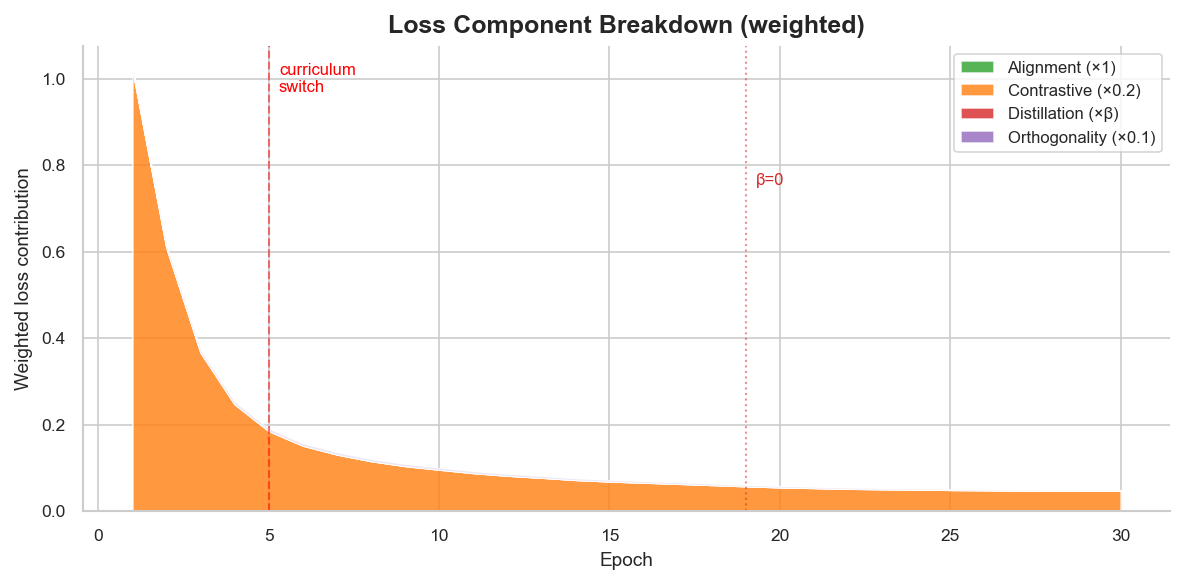

In [5]:
if len(train_metrics) > 0:
    alpha = config.get("alpha", 0.2)
    gamma = config.get("gamma", 0.1)

    epochs = train_metrics["epoch"]
    align_w = train_metrics["train/align"]
    contrastive_w = alpha * train_metrics["train/contrastive"]
    distill_w = train_metrics["beta"] * train_metrics["train/distill"]
    orth_w = gamma * train_metrics["train/orth"]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.stackplot(
        epochs, align_w, contrastive_w, distill_w, orth_w,
        labels=[
            "Alignment (×1)",
            f"Contrastive (×{alpha})",
            "Distillation (×β)",
            f"Orthogonality (×{gamma})",
        ],
        colors=["#2ca02c", "#ff7f0e", "#d62728", "#9467bd"],
        alpha=0.8,
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weighted loss contribution")
    ax.set_title("Loss Component Breakdown (weighted)", fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)

    curriculum_epoch = config.get("curriculum_warmup", 5)
    if epochs.max() >= curriculum_epoch:
        ax.axvline(curriculum_epoch, color="red", linestyle="--", alpha=0.5, linewidth=1)
        ax.text(curriculum_epoch + 0.3, ax.get_ylim()[1] * 0.9, "curriculum\nswitch",
                fontsize=8, color="red")

    # Mark beta=0 transition
    beta_zero_epoch = train_metrics.loc[train_metrics["beta"] == 0, "epoch"]
    if len(beta_zero_epoch) > 0:
        bze = beta_zero_epoch.iloc[0]
        ax.axvline(bze, color="#d62728", linestyle=":", alpha=0.5, linewidth=1)
        ax.text(bze + 0.3, ax.get_ylim()[1] * 0.7, "β=0", fontsize=8, color="#d62728")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "loss_breakdown.png", bbox_inches="tight")
    plt.show()
else:
    print("No train metrics to plot.")

## 6. Eval Progression Over Training

The spectral graph encoder completed 30 epochs of joint multi-teacher training. This section analyzes eval progression across training, noise robustness, and the isomer confusion pattern.

In [6]:
def parse_eval_long(eval_metrics):
    """Reshape wide eval_metrics into tidy long-form: (epoch, isomer_set, noise, metric, value)."""
    noise_order = ["clean", "mild", "moderate", "severe", "extreme"]
    records = []
    for _, row in eval_metrics.iterrows():
        epoch = row["epoch"]
        for col, val in row.items():
            if not col.startswith("eval/"):
                continue
            # col format: "eval/{isomer_set}/{noise}/{metric}"
            parts = col.split("/")
            if len(parts) != 4:
                continue
            _, isomer_set, noise, metric = parts
            records.append({
                "epoch": int(epoch),
                "isomer_set": isomer_set,
                "noise": noise,
                "metric": metric,
                "value": val,
            })
    df = pd.DataFrame(records)
    df["noise"] = pd.Categorical(df["noise"], categories=noise_order, ordered=True)
    return df

eval_long = parse_eval_long(eval_metrics)
print(f"Eval long-form: {len(eval_long)} rows, epochs {eval_long['epoch'].min()}-{eval_long['epoch'].max()}")
print(f"Isomer sets: {eval_long['isomer_set'].unique().tolist()}")
print(f"Metrics: {eval_long['metric'].unique().tolist()}")

Eval long-form: 1800 rows, epochs 1-30
Isomer sets: ['0% isomer', '50% isomer', '100% isomer']
Metrics: ['top1', 'top5', 'mrr', 'cls1']


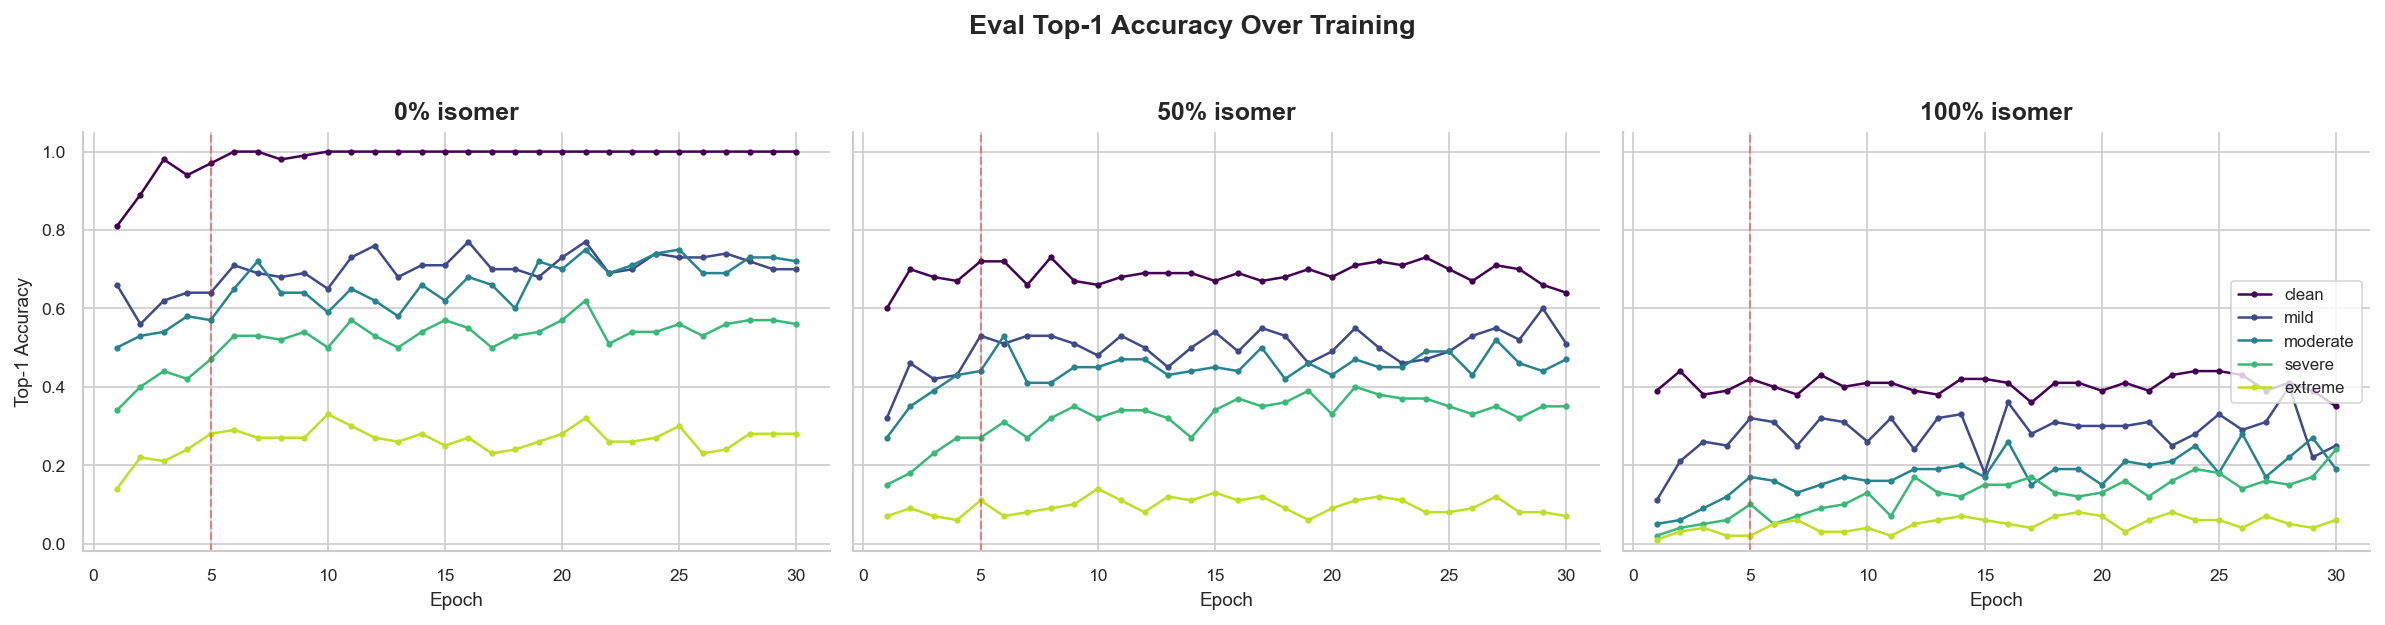

In [7]:
isomer_sets = ["0% isomer", "50% isomer", "100% isomer"]
noise_levels = ["clean", "mild", "moderate", "severe", "extreme"]
noise_colors = dict(zip(noise_levels, plt.cm.viridis(np.linspace(0, 0.9, 5))))

top1 = eval_long[eval_long["metric"] == "top1"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, iset in zip(axes, isomer_sets):
    subset = top1[top1["isomer_set"] == iset]
    for noise in noise_levels:
        ns = subset[subset["noise"] == noise].sort_values("epoch")
        ax.plot(ns["epoch"], ns["value"], marker=".", markersize=4,
                linewidth=1.2, color=noise_colors[noise], label=noise)
    ax.axvline(5, color="red", linestyle="--", alpha=0.4, linewidth=1)
    ax.set_xlabel("Epoch")
    ax.set_title(iset, fontweight="bold")
    ax.set_ylim(-0.02, 1.05)

axes[0].set_ylabel("Top-1 Accuracy")
axes[2].legend(fontsize=8, loc="center right")
plt.suptitle("Eval Top-1 Accuracy Over Training", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "eval_top1_progression.png", bbox_inches="tight")
plt.show()

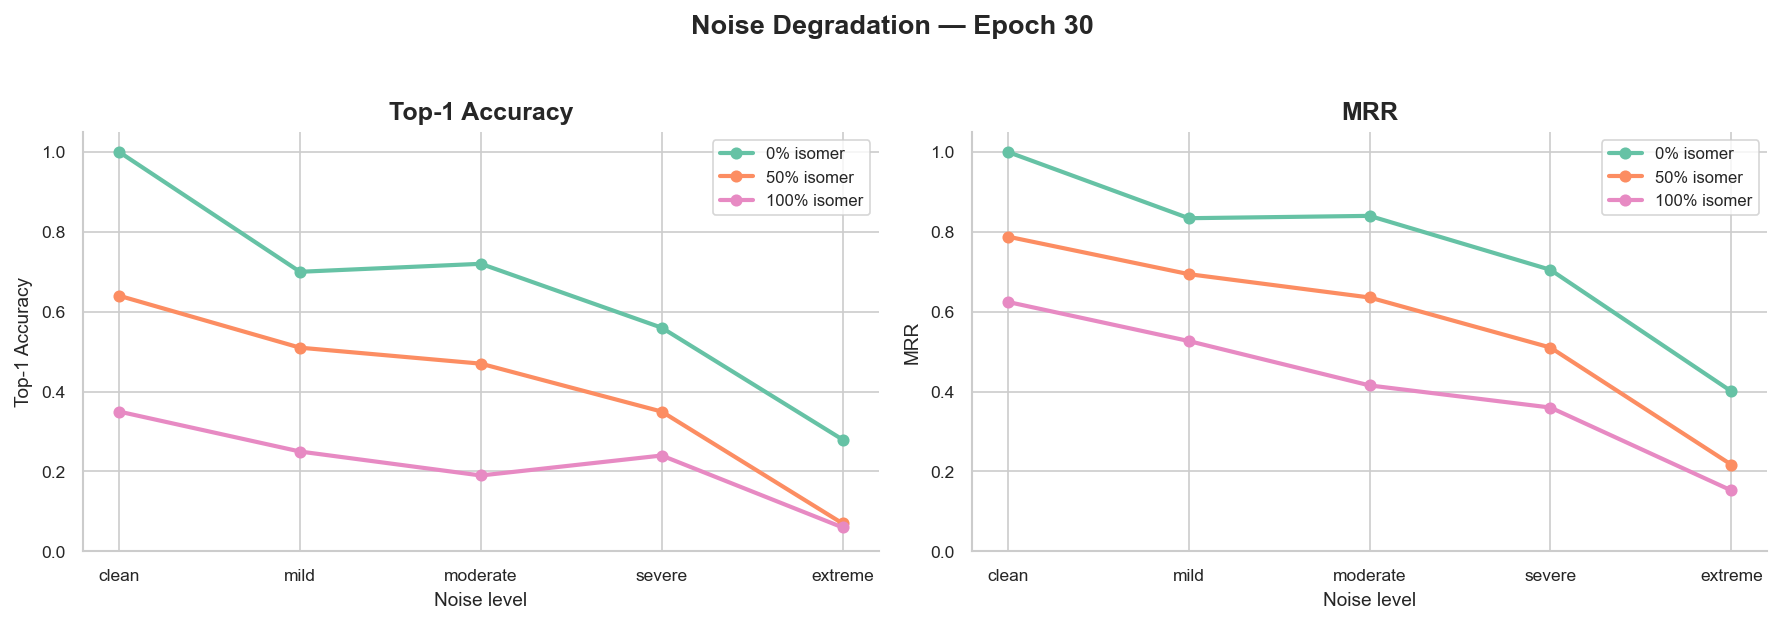

In [8]:
latest_epoch = eval_long["epoch"].max()
latest = eval_long[eval_long["epoch"] == latest_epoch]
set_colors = dict(zip(isomer_sets, plt.cm.Set2(np.linspace(0, 0.4, 3))))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, label in zip(axes, ["top1", "mrr"], ["Top-1 Accuracy", "MRR"]):
    sub = latest[latest["metric"] == metric]
    for iset in isomer_sets:
        s = sub[sub["isomer_set"] == iset].sort_values("noise")
        ax.plot(s["noise"].astype(str), s["value"], marker="o", linewidth=2,
                color=set_colors[iset], label=iset)
    ax.set_xlabel("Noise level")
    ax.set_ylabel(label)
    ax.set_title(label, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)

plt.suptitle(f"Noise Degradation — Epoch {latest_epoch}",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "noise_degradation_snapshot.png", bbox_inches="tight")
plt.show()

## 7. Benchmark Results

Load benchmark results from the parquet file and compare across noise levels and eval sets.

In [9]:
bench_path = Path("../data/benchmark_custom_encoder.parquet")
if bench_path.exists():
    bench = pd.read_parquet(bench_path)
    display(bench.style.format({
        "top_1": "{:.3f}", "top_5": "{:.3f}", "top_10": "{:.3f}",
        "mrr": "{:.3f}", "class_top_1": "{:.3f}", "class_top_5": "{:.3f}",
        "mean_query_ms": "{:.1f}",
    }).set_caption("Spectral Graph Encoder Benchmark Results"))
else:
    print(f"No benchmark file at {bench_path} — run scripts/benchmark_custom_encoder.py first.")

,method,noise,top_1,top_5,top_10,mrr,class_top_1,class_top_5,n_queries,mean_candidates,median_candidates,mean_query_ms,eval_set
0,custom_graph,clean,1.000,1.000,1.000,1.000,1.000,1.000,100,268.380000,155.500000,0.7,0% isomer
1,custom_graph,mild,0.700,1.000,1.000,0.834,0.980,1.000,100,268.380000,155.500000,0.7,0% isomer
2,custom_graph,moderate,0.730,1.000,1.000,0.845,0.930,1.000,100,268.380000,155.500000,0.7,0% isomer
3,custom_graph,severe,0.570,0.890,0.910,0.711,0.800,0.930,100,268.380000,155.500000,0.7,0% isomer
4,custom_graph,extreme,0.280,0.550,0.670,0.400,0.420,0.620,100,268.380000,155.500000,0.7,0% isomer
5,custom_graph,clean,0.660,0.980,1.000,0.806,1.000,1.000,100,285.850000,263.000000,0.7,50% isomer
6,custom_graph,mild,0.600,0.940,0.990,0.743,0.970,1.000,100,285.850000,263.000000,0.7,50% isomer
7,custom_graph,moderate,0.440,0.840,0.910,0.616,0.950,0.980,100,285.850000,263.000000,0.7,50% isomer
8,custom_graph,severe,0.350,0.710,0.820,0.512,0.870,0.930,100,285.850000,263.000000,0.7,50% isomer
9,custom_graph,extreme,0.080,0.380,0.520,0.215,0.520,0.640,100,285.700000,263.000000,0.7,50% isomer


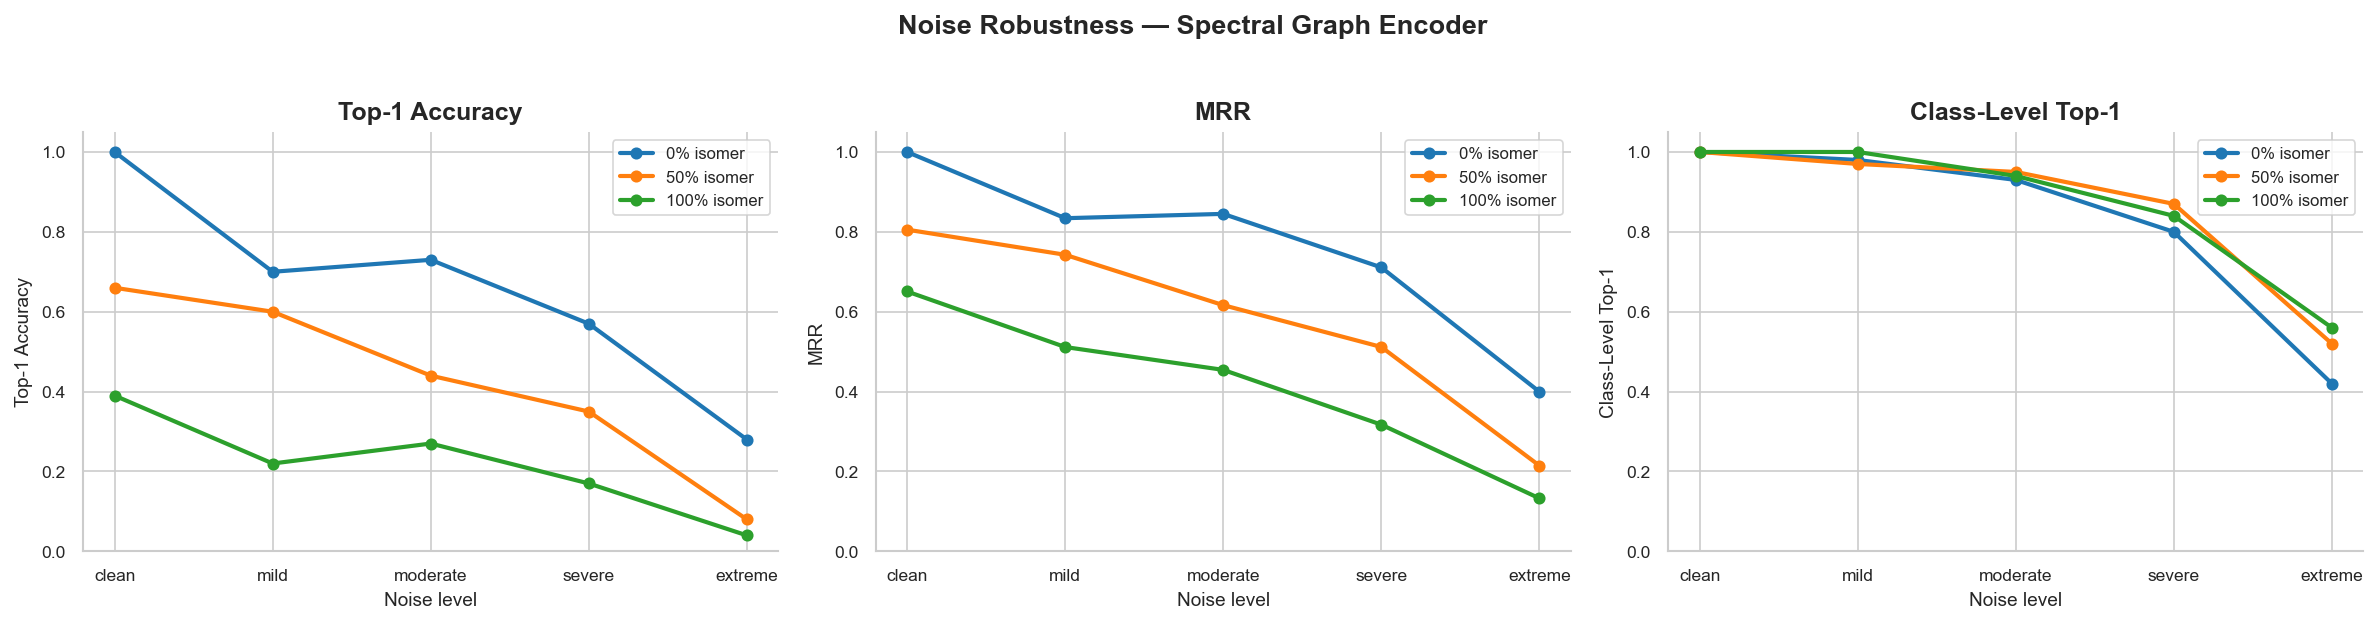

In [10]:
if bench_path.exists():
    noise_order = ["clean", "mild", "moderate", "severe", "extreme"]
    bench["noise"] = pd.Categorical(bench["noise"], categories=noise_order, ordered=True)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for ax, (metric, label) in zip(axes, [
        ("top_1", "Top-1 Accuracy"),
        ("mrr", "MRR"),
        ("class_top_1", "Class-Level Top-1"),
    ]):
        for eval_set in bench["eval_set"].unique():
            subset = bench[bench["eval_set"] == eval_set].sort_values("noise")
            ax.plot(subset["noise"].astype(str), subset[metric],
                    marker="o", linewidth=2, label=eval_set)
        ax.set_xlabel("Noise level")
        ax.set_ylabel(label)
        ax.set_title(label, fontweight="bold")
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1.05)

    plt.suptitle("Noise Robustness — Spectral Graph Encoder",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "custom_encoder_noise_robustness.png", bbox_inches="tight")
    plt.show()

## 8. Observations & Next Steps

- Clean top-1 = 100% on 0% isomer -- the encoder captures spectral identity perfectly when no isomers confuse it
- Noise robustness lags behind DreaMS, especially at severe/extreme levels
- Isomer disambiguation is the core challenge: same fragments, different arrangement -> same embedding

## 9. Root Cause Analysis & Decision: V2 Encoder

Two structural issues explain V1's noise sensitivity:
1. **Categorical intensity collapse:** LipidBlast uses ~4 discrete intensity levels. V1's continuous intensity features waste capacity on noise in these quantized values.
2. **Edge feature sparsity:** 21 of 25 edge features are binary neutral-loss flags, mostly zero. The dense edge matrix is ~95% sparse, diluting the few informative edges.

These findings motivate a V2 redesign with quantized intensity bins and compressed edge features.

---
## Part 2 — V2 Spectral Graph Encoder (539K params)
## 10. V1 vs Cosine Analysis

0% isomer — Top-1 Accuracy:
   noise  Cosine  V1 Encoder  V2 Encoder  V1 gap  V2 gap
   clean   1.000       1.000       0.980   0.000  -0.020
    mild   0.990       0.700       0.670  -0.290  -0.320
moderate   0.960       0.730       0.650  -0.230  -0.310
  severe   0.790       0.570       0.430  -0.220  -0.360
 extreme   0.430       0.280       0.200  -0.150  -0.230

V1 avg gap vs cosine: -0.178
V2 avg gap vs cosine: -0.248


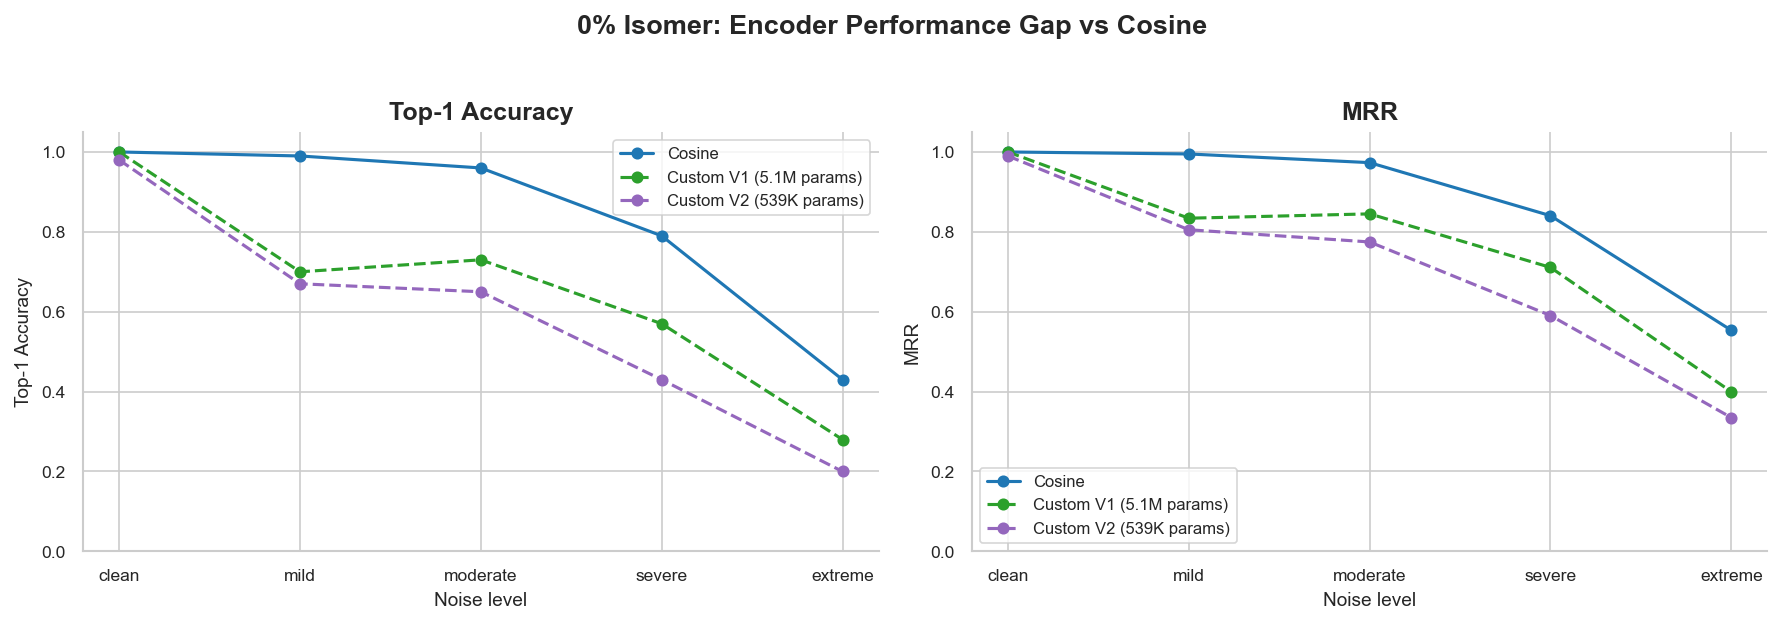

In [11]:
# Load all benchmark results
classical = pd.read_parquet(DATA_DIR / "benchmark_classical.parquet")
cosine_df = classical[classical["method"] == "cosine"]
custom_v1 = pd.read_parquet(DATA_DIR / "benchmark_custom_encoder.parquet")
custom_v2 = pd.read_parquet(DATA_DIR / "benchmark_custom_encoder_v2.parquet")

NOISE_ORDER = ["clean", "mild", "moderate", "severe", "extreme"]

# Build comparison table: 0% isomer only
gap_rows = []
for noise in NOISE_ORDER:
    cos_val = cosine_df[(cosine_df["eval_set"] == "0% isomer") & (cosine_df["noise"] == noise)]["top_1"].values[0]
    v1_val = custom_v1[(custom_v1["eval_set"] == "0% isomer") & (custom_v1["noise"] == noise)]["top_1"].values[0]
    v2_val = custom_v2[(custom_v2["eval_set"] == "0% isomer") & (custom_v2["noise"] == noise)]["top_1"].values[0]
    gap_rows.append({
        "noise": noise,
        "Cosine": cos_val,
        "V1 Encoder": v1_val,
        "V2 Encoder": v2_val,
        "V1 gap": v1_val - cos_val,
        "V2 gap": v2_val - cos_val,
    })
gap_df = pd.DataFrame(gap_rows)
print("0% isomer — Top-1 Accuracy:")
print(gap_df.to_string(index=False, float_format="{:.3f}".format))
print()
print(f"V1 avg gap vs cosine: {gap_df['V1 gap'].mean():+.3f}")
print(f"V2 avg gap vs cosine: {gap_df['V2 gap'].mean():+.3f}")

# Visual: V1 and V2 vs cosine on 0% isomer
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (metric, label) in zip(axes, [("top_1", "Top-1 Accuracy"), ("mrr", "MRR")]):
    for df_method, name, color, ls in [
        (cosine_df, "Cosine", "#1f77b4", "-"),
        (custom_v1, "Custom V1 (5.1M params)", "#2ca02c", "--"),
        (custom_v2, "Custom V2 (539K params)", "#9467bd", "--"),
    ]:
        sub = df_method[df_method["eval_set"] == "0% isomer"].copy()
        sub["noise"] = pd.Categorical(sub["noise"], categories=NOISE_ORDER, ordered=True)
        sub = sub.sort_values("noise")
        ax.plot(sub["noise"].astype(str), sub[metric], marker="o", linewidth=1.5,
                color=color, linestyle=ls, label=name)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Noise level")
    ax.set_ylabel(label)
    ax.set_title(label, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("0% Isomer: Encoder Performance Gap vs Cosine",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_vs_cosine_gap.png", bbox_inches="tight", dpi=150)
plt.show()

Removed 384 spectra with <2 peaks


Total peaks: 3,203,892
Unique relative intensity values: 110
Peaks in 7 canonical tiers: 2,836,988 (88.5%)


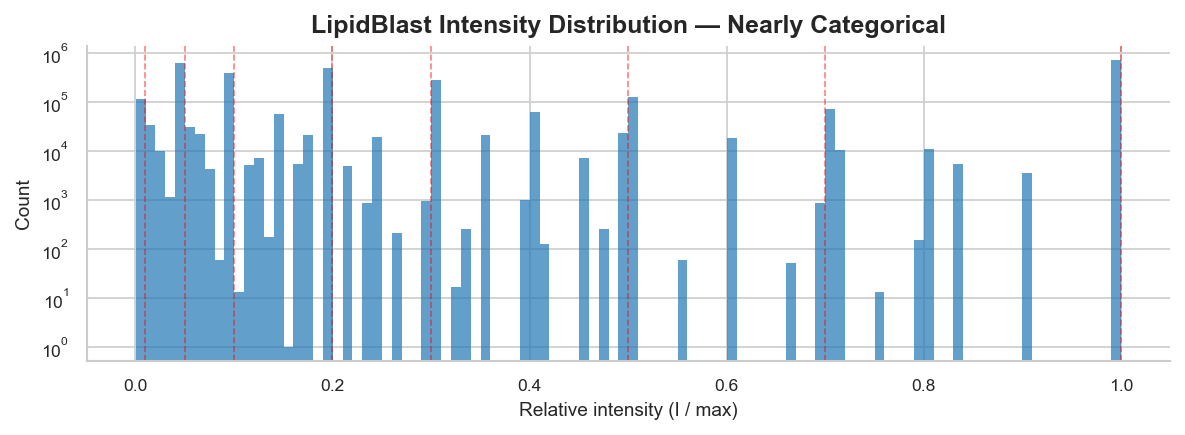

/home/weiyi/lipid_identification/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NL flag sparsity: 99.7% zeros
Mean NL flags per spectrum: 3.6
Spectra with zero NL flags: 146/500


In [12]:
from src.data.loader import load_library

lib_df = load_library()

# Count unique intensity values
all_ints = []
for ints in lib_df["intensity_list"]:
    all_ints.extend(ints)
all_ints = np.array(all_ints)
max_per_spec = lib_df["intensity_list"].apply(lambda x: max(x))
rel_ints = []
for ints, mx in zip(lib_df["intensity_list"], max_per_spec):
    rel_ints.extend(np.array(ints) / mx)
rel_ints = np.array(rel_ints)

# Canonical tiers
TIERS = [0.01, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 1.00]
tier_counts = 0
for t in TIERS:
    tier_counts += np.sum(np.abs(rel_ints - t) < 0.005)

print(f"Total peaks: {len(rel_ints):,}")
print(f"Unique relative intensity values: {len(np.unique(np.round(rel_ints, 4)))}")
print(f"Peaks in 7 canonical tiers: {tier_counts:,} ({tier_counts/len(rel_ints)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(rel_ints, bins=100, color="#1f77b4", alpha=0.7, edgecolor="none")
for t in TIERS:
    ax.axvline(t, color="red", linestyle="--", alpha=0.5, linewidth=0.8)
ax.set_xlabel("Relative intensity (I / max)")
ax.set_ylabel("Count")
ax.set_title("LipidBlast Intensity Distribution — Nearly Categorical", fontweight="bold")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

from src.models.spectral_graph_encoder import spectrum_to_padded

# Sample spectra and check NL flag sparsity
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(lib_df), 500, replace=False)

nl_flag_nonzero = []
total_edge_entries = 0
for idx in sample_idx:
    row = lib_df.iloc[idx]
    data = spectrum_to_padded(row["mz_list"], row["intensity_list"], row["precursor_mz"])
    n = data["n_nodes"]
    # NL flags are dims 3-23 of edge_attr (21 binary flags)
    nl_flags = data["edge_attr"][:n, :n, 3:24]
    total_edge_entries += nl_flags.size
    nl_flag_nonzero.append(nl_flags.sum())

sparsity = 1.0 - sum(nl_flag_nonzero) / total_edge_entries
print(f"NL flag sparsity: {sparsity*100:.1f}% zeros")
print(f"Mean NL flags per spectrum: {np.mean(nl_flag_nonzero):.1f}")
print(f"Spectra with zero NL flags: {sum(1 for x in nl_flag_nonzero if x == 0)}/{len(nl_flag_nonzero)}")

## 11. V2 Design Decisions

| Change | V1 | V2 | Rationale |
|--------|----|----|-----------|
| **Intensity features** | continuous rel_intensity + sqrt (2 dims) | 7-bin one-hot + ordinal rank (8 dims) | Eliminates categorical→continuous gap |
| **Edge features** | 25 dims (21 sparse NL flags) | 4 dims (continuous only) | Removes 98.9%-zero channels |
| **NL information** | Per-edge binary flags | Per-node NL count (normalized) | Same info, dense representation |
| **Architecture** | 6 layers, 256d, 8 heads (5.1M params) | 2 layers, 128d, 4 heads (539K params) | 5-node graphs don't need depth |
| **Checkpoint selection** | val/align (ChemBERTa MSE) | Composite retrieval metric | Selects for actual retrieval |
| **Contrastive weight α** | 0.2 | 0.5 | More gradient to contrastive |
| **Temperature τ** | 0.07 | 0.05 | Sharper negative rejection |

## 12. V2 Training Curves

In [13]:
# Find V2 log files
v2_logs = sorted(LOGS_DIR.glob("custom_encoder_v2*_metrics.jsonl"))
v2_text_logs = sorted(LOGS_DIR.glob("custom_encoder_v2*.log"))

if not v2_logs:
    print("No V2 metrics JSONL found")
else:
    v2_jsonl = v2_logs[-1]
    rows = []
    with open(v2_jsonl) as f:
        for line in f:
            rows.append(json.loads(line))
    print(f"Loaded {v2_jsonl.name}: {len(rows)} entries")

    v2_train = pd.DataFrame([r for r in rows if "train/loss" in r])
    v2_eval = pd.DataFrame([r for r in rows if any(k.startswith("eval/") for k in r)])
    print(f"  Train epochs: {len(v2_train)}, Eval epochs: {len(v2_eval)}")

# Parse batch-level metrics from text log
if v2_text_logs:
    v2_log_path = v2_text_logs[-1]
    pattern = re.compile(r"\[step (\d+)\] (.+)")
    batch_rows = []
    with open(v2_log_path) as f:
        for line in f:
            m = pattern.search(line)
            if not m:
                continue
            step = int(m.group(1))
            kvs = {"_step": step}
            for pair in m.group(2).split(" | "):
                k, v = pair.split("=")
                kvs[k.strip()] = float(v)
            batch_rows.append(kvs)
    v2_batch = pd.DataFrame(batch_rows)
    print(f"Loaded {v2_log_path.name}: {len(v2_batch)} batch entries")

# Extract config
v2_config = {}
if v2_text_logs:
    with open(v2_text_logs[-1]) as f:
        first = f.readline()
    if "Config:" in first:
        v2_config = json.loads(first.split("Config: ")[1])
    print(f"V2 config: {v2_config.get('epochs')} epochs, lr={v2_config.get('lr')}, "
          f"alpha={v2_config.get('alpha')}, temp={v2_config.get('temperature')}")

Loaded custom_encoder_v2_joint_20260226_182443_metrics.jsonl: 60 entries
  Train epochs: 30, Eval epochs: 30
Loaded custom_encoder_v2_joint_20260226_182443.log: 645 batch entries
V2 config: 30 epochs, lr=0.0003, alpha=0.5, temp=0.05


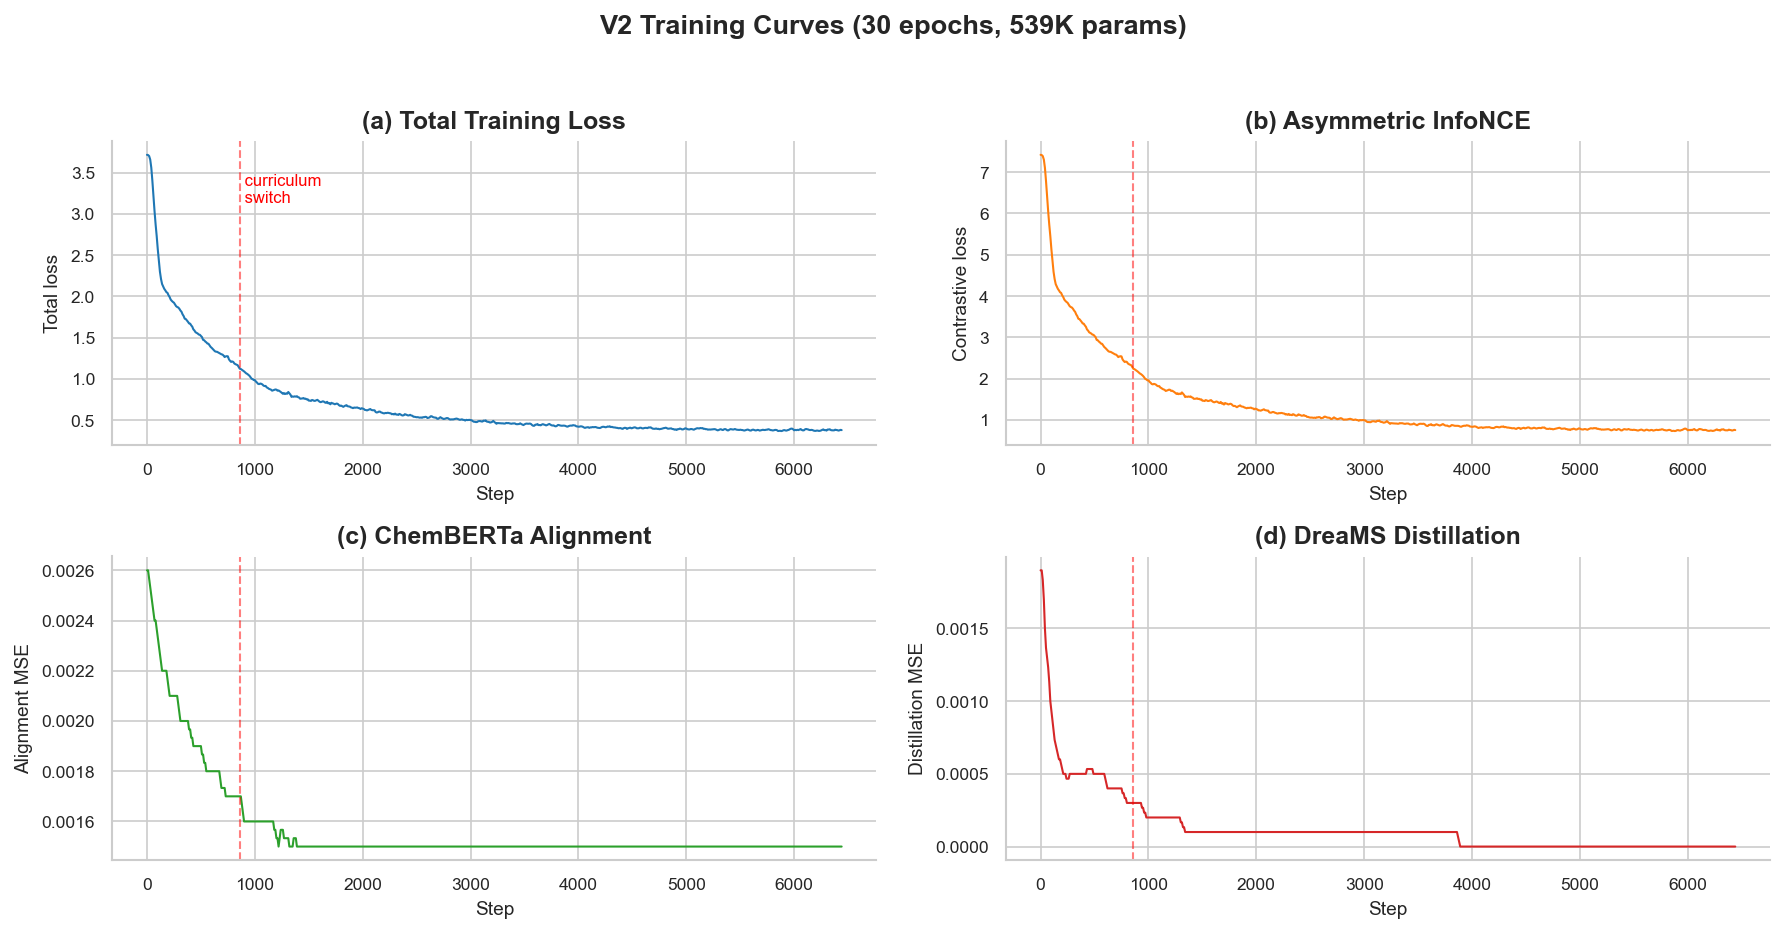

In [14]:
if len(v2_batch) > 0:
    window = max(1, len(v2_batch) // 200)

    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    axes = axes.flatten()

    plots = [
        ("batch/loss", "Total loss", "#1f77b4", "(a) Total Training Loss"),
        ("batch/contrastive", "Contrastive loss", "#ff7f0e", "(b) Asymmetric InfoNCE"),
        ("batch/align", "Alignment MSE", "#2ca02c", "(c) ChemBERTa Alignment"),
        ("batch/distill", "Distillation MSE", "#d62728", "(d) DreaMS Distillation"),
    ]

    for ax, (col, ylabel, color, title) in zip(axes, plots):
        if col not in v2_batch.columns:
            ax.set_title(f"{title} (N/A)")
            continue
        smoothed = v2_batch[col].rolling(window, min_periods=1).mean()
        ax.plot(v2_batch["_step"], smoothed, color=color, linewidth=1)
        ax.set_xlabel("Step")
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight="bold")

    curriculum_warmup = v2_config.get("curriculum_warmup", 5)
    if v2_batch["batch/epoch"].max() >= curriculum_warmup:
        ts = v2_batch.loc[v2_batch["batch/epoch"] >= curriculum_warmup, "_step"].iloc[0]
        for ax in axes:
            ax.axvline(ts, color="red", linestyle="--", alpha=0.5, linewidth=1)
        axes[0].text(ts, axes[0].get_ylim()[1] * 0.9, " curriculum\n switch",
                     fontsize=8, color="red", va="top")

    plt.suptitle("V2 Training Curves (30 epochs, 539K params)",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "v2_training_curves.png", bbox_inches="tight")
    plt.show()

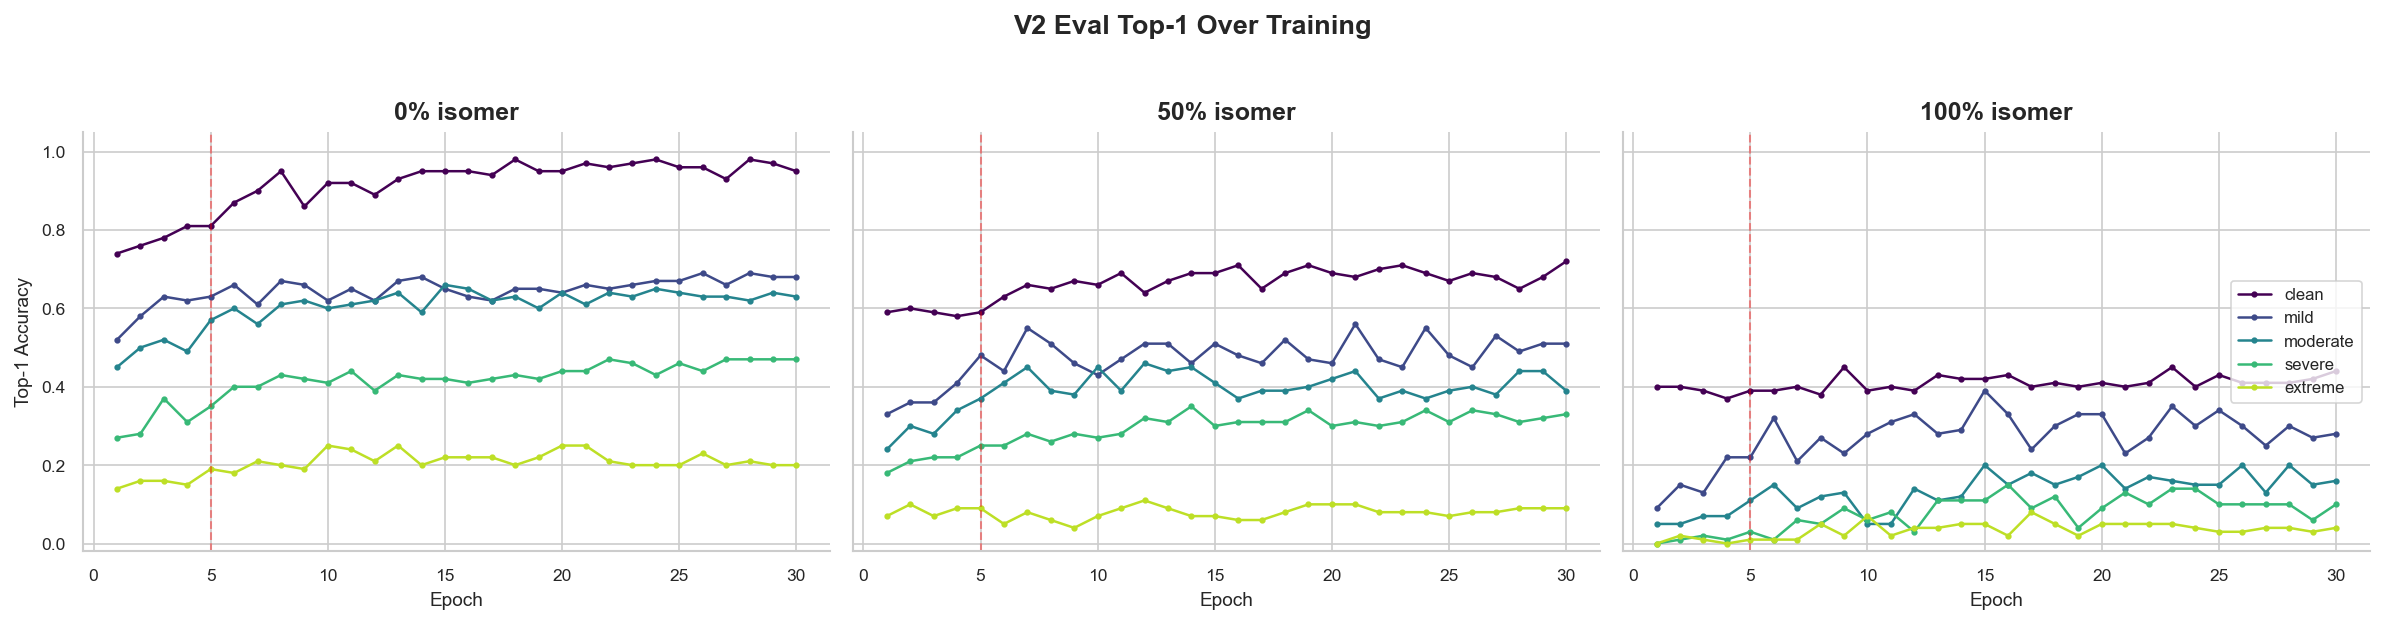

In [15]:
def parse_eval_long(eval_df):
    noise_order = ["clean", "mild", "moderate", "severe", "extreme"]
    records = []
    for _, row in eval_df.iterrows():
        epoch = row["epoch"]
        for col, val in row.items():
            if not col.startswith("eval/"):
                continue
            parts = col.split("/")
            if len(parts) != 4:
                continue
            _, isomer_set, noise, metric = parts
            records.append({
                "epoch": int(epoch), "isomer_set": isomer_set,
                "noise": noise, "metric": metric, "value": val,
            })
    df = pd.DataFrame(records)
    df["noise"] = pd.Categorical(df["noise"], categories=noise_order, ordered=True)
    return df

if len(v2_eval) > 0:
    v2_eval_long = parse_eval_long(v2_eval)
    noise_colors = dict(zip(NOISE_ORDER, plt.cm.viridis(np.linspace(0, 0.9, 5))))

    top1 = v2_eval_long[v2_eval_long["metric"] == "top1"]
    isomer_sets = ["0% isomer", "50% isomer", "100% isomer"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
    for ax, iset in zip(axes, isomer_sets):
        subset = top1[top1["isomer_set"] == iset]
        for noise in NOISE_ORDER:
            ns = subset[subset["noise"] == noise].sort_values("epoch")
            ax.plot(ns["epoch"], ns["value"], marker=".", markersize=4,
                    linewidth=1.2, color=noise_colors[noise], label=noise)
        ax.axvline(v2_config.get("curriculum_warmup", 5), color="red",
                   linestyle="--", alpha=0.4, linewidth=1)
        ax.set_xlabel("Epoch")
        ax.set_title(iset, fontweight="bold")
        ax.set_ylim(-0.02, 1.05)

    axes[0].set_ylabel("Top-1 Accuracy")
    axes[2].legend(fontsize=8, loc="center right")
    plt.suptitle("V2 Eval Top-1 Over Training", fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "v2_eval_progression.png", bbox_inches="tight")
    plt.show()

    # Show composite score progression
    if "composite_score" in v2_train.columns:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.plot(v2_train["epoch"], v2_train["composite_score"], "o-", color="#1f77b4", linewidth=1.5)
        best_idx = v2_train["composite_score"].idxmax()
        best_epoch = v2_train.loc[best_idx, "epoch"]
        best_score = v2_train.loc[best_idx, "composite_score"]
        ax.axhline(best_score, color="green", linestyle="--", alpha=0.5)
        ax.annotate(f"Best: {best_score:.4f} (epoch {best_epoch:.0f})",
                    xy=(best_epoch, best_score), fontsize=9,
                    xytext=(best_epoch + 2, best_score - 0.02),
                    arrowprops=dict(arrowstyle="->", color="green", lw=0.8))
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Composite Retrieval Score")
        ax.set_title("V2 Checkpoint Selection Metric", fontweight="bold")
        plt.tight_layout()
        plt.show()

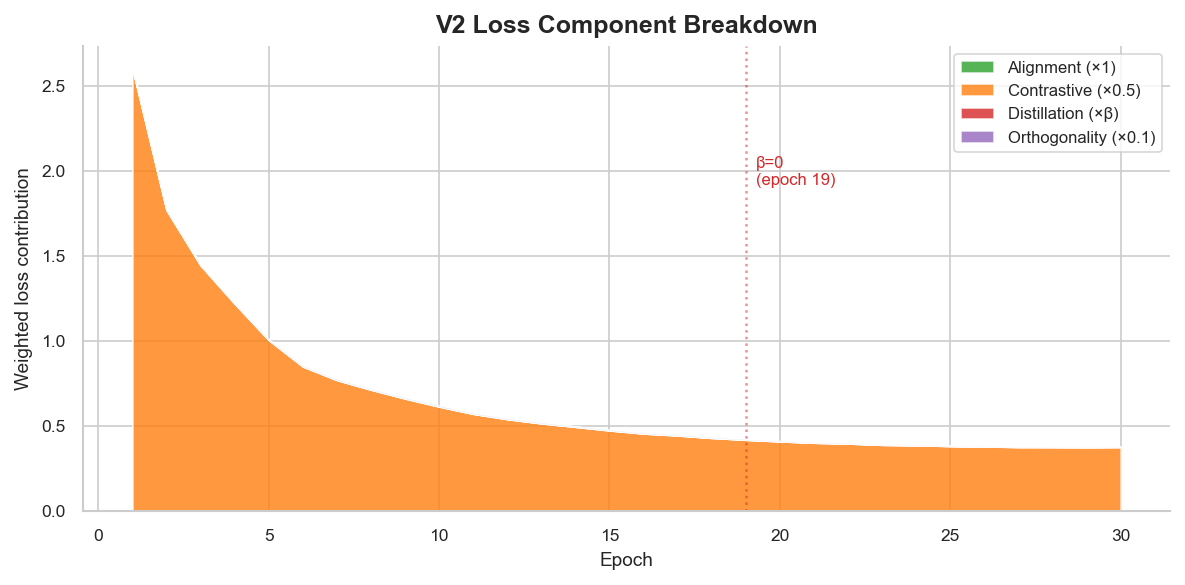

In [16]:
if len(v2_train) > 0:
    alpha = v2_config.get("alpha", 0.5)
    gamma = v2_config.get("gamma", 0.1)
    epochs = v2_train["epoch"]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.stackplot(
        epochs,
        v2_train["train/align"],
        alpha * v2_train["train/contrastive"],
        v2_train["beta"] * v2_train["train/distill"],
        gamma * v2_train["train/orth"],
        labels=["Alignment (×1)", f"Contrastive (×{alpha})",
                "Distillation (×β)", f"Orthogonality (×{gamma})"],
        colors=["#2ca02c", "#ff7f0e", "#d62728", "#9467bd"],
        alpha=0.8,
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weighted loss contribution")
    ax.set_title("V2 Loss Component Breakdown", fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)

    beta_zero = v2_train.loc[v2_train["beta"] == 0, "epoch"]
    if len(beta_zero) > 0:
        bze = beta_zero.iloc[0]
        ax.axvline(bze, color="#d62728", linestyle=":", alpha=0.5)
        ax.text(bze + 0.3, ax.get_ylim()[1] * 0.7, f"β=0\n(epoch {bze:.0f})",
                fontsize=8, color="#d62728")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "v2_loss_breakdown.png", bbox_inches="tight")
    plt.show()

## 13. V2 vs V1 Comparison

In [17]:
SET_ORDER = ["0% isomer", "50% isomer", "100% isomer"]

# Full comparison table
comp_rows = []
for eval_set in SET_ORDER:
    for noise in NOISE_ORDER:
        cos = cosine_df[(cosine_df["eval_set"] == eval_set) & (cosine_df["noise"] == noise)]
        v1 = custom_v1[(custom_v1["eval_set"] == eval_set) & (custom_v1["noise"] == noise)]
        v2 = custom_v2[(custom_v2["eval_set"] == eval_set) & (custom_v2["noise"] == noise)]
        comp_rows.append({
            "eval_set": eval_set, "noise": noise,
            "cos_top1": cos["top_1"].values[0],
            "v1_top1": v1["top_1"].values[0],
            "v2_top1": v2["top_1"].values[0],
            "cos_mrr": cos["mrr"].values[0],
            "v1_mrr": v1["mrr"].values[0],
            "v2_mrr": v2["mrr"].values[0],
        })
comp = pd.DataFrame(comp_rows)
comp["v2_vs_v1"] = comp["v2_top1"] - comp["v1_top1"]
comp["v2_vs_cos"] = comp["v2_top1"] - comp["cos_top1"]

print("Full comparison (Top-1 Accuracy):")
print(comp[["eval_set", "noise", "cos_top1", "v1_top1", "v2_top1", "v2_vs_v1", "v2_vs_cos"]]
      .to_string(index=False, float_format="{:.3f}".format))
print()
print(f"V2 vs V1 average delta: {comp['v2_vs_v1'].mean():+.3f}")
print(f"V2 vs Cosine average delta: {comp['v2_vs_cos'].mean():+.3f}")

Full comparison (Top-1 Accuracy):
   eval_set    noise  cos_top1  v1_top1  v2_top1  v2_vs_v1  v2_vs_cos
  0% isomer    clean     1.000    1.000    0.980    -0.020     -0.020
  0% isomer     mild     0.990    0.700    0.670    -0.030     -0.320
  0% isomer moderate     0.960    0.730    0.650    -0.080     -0.310
  0% isomer   severe     0.790    0.570    0.430    -0.140     -0.360
  0% isomer  extreme     0.430    0.280    0.200    -0.080     -0.230
 50% isomer    clean     0.700    0.660    0.690     0.030     -0.010
 50% isomer     mild     0.700    0.600    0.550    -0.050     -0.150
 50% isomer moderate     0.650    0.440    0.370    -0.070     -0.280
 50% isomer   severe     0.530    0.350    0.340    -0.010     -0.190
 50% isomer  extreme     0.220    0.080    0.080     0.000     -0.140
100% isomer    clean     0.410    0.390    0.400     0.010     -0.010
100% isomer     mild     0.390    0.220    0.300     0.080     -0.090
100% isomer moderate     0.360    0.270    0.150    -0.1

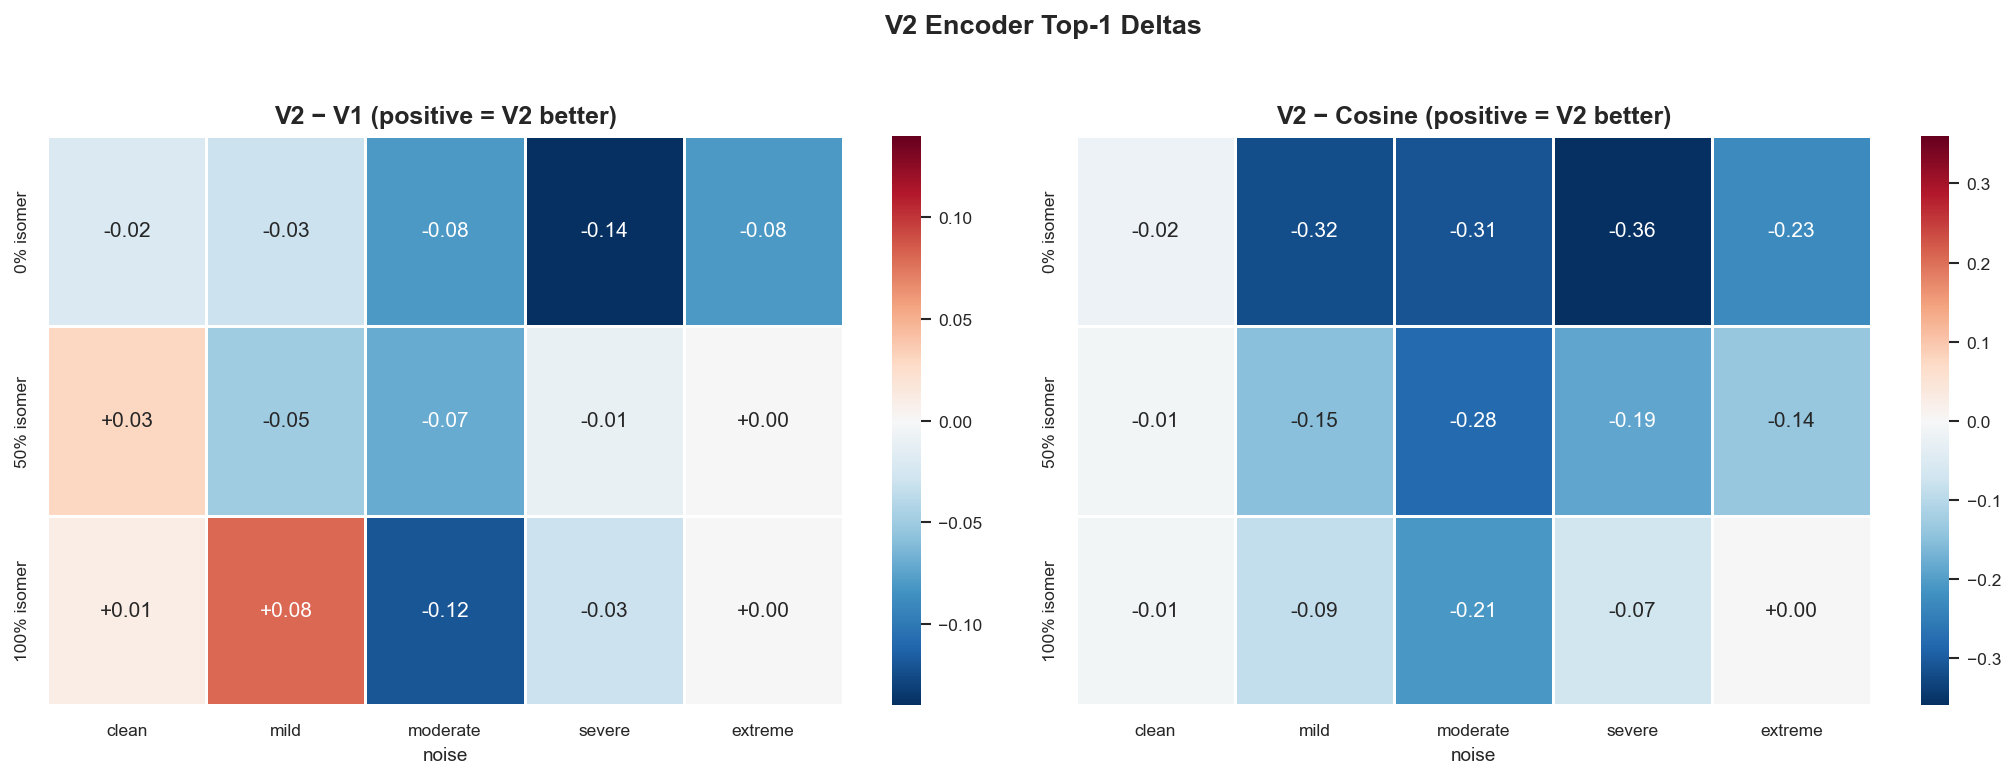

V2 Encoder Full Benchmark:


,method,noise,top_1,top_5,top_10,mrr,class_top_1,class_top_5,n_queries,mean_candidates,median_candidates,mean_query_ms,eval_set
0,custom_graph_v2,clean,0.980,1.000,1.000,0.990,1.000,1.000,100,268.380000,155.500000,0.761024,0% isomer
1,custom_graph_v2,mild,0.670,0.980,0.990,0.805,0.970,0.980,100,268.380000,155.500000,0.761024,0% isomer
2,custom_graph_v2,moderate,0.650,0.940,0.970,0.775,0.890,0.950,100,268.380000,155.500000,0.761024,0% isomer
3,custom_graph_v2,severe,0.430,0.840,0.890,0.591,0.700,0.890,100,268.380000,155.500000,0.761024,0% isomer
4,custom_graph_v2,extreme,0.200,0.520,0.590,0.335,0.430,0.620,100,268.380000,155.500000,0.761024,0% isomer
5,custom_graph_v2,clean,0.690,0.970,1.000,0.825,1.000,1.000,100,285.850000,263.000000,0.767053,50% isomer
6,custom_graph_v2,mild,0.550,0.900,0.940,0.713,0.980,0.980,100,285.850000,263.000000,0.767053,50% isomer
7,custom_graph_v2,moderate,0.370,0.780,0.860,0.545,0.930,0.970,100,285.850000,263.000000,0.767053,50% isomer
8,custom_graph_v2,severe,0.340,0.590,0.670,0.453,0.790,0.900,100,285.850000,263.000000,0.767053,50% isomer
9,custom_graph_v2,extreme,0.080,0.300,0.440,0.187,0.510,0.610,100,285.700000,263.000000,0.767053,50% isomer


In [18]:
# Delta heatmaps: V2 vs V1, V2 vs Cosine
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (delta_col, title) in zip(axes, [
    ("v2_vs_v1", "V2 − V1 (positive = V2 better)"),
    ("v2_vs_cos", "V2 − Cosine (positive = V2 better)"),
]):
    pivot = comp.pivot_table(index="eval_set", columns="noise", values=delta_col)
    pivot = pivot.loc[SET_ORDER, NOISE_ORDER]
    vmax = max(0.1, abs(pivot.values).max())
    sns.heatmap(pivot, annot=True, fmt="+.2f", cmap="RdBu_r",
                center=0, vmin=-vmax, vmax=vmax, ax=ax,
                linewidths=0.5, linecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("")

plt.suptitle("V2 Encoder Top-1 Deltas", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_deltas.png", bbox_inches="tight", dpi=150)
plt.show()

# V2 benchmark detail table
print("V2 Encoder Full Benchmark:")
display(custom_v2.style.format({
    "top_1": "{:.3f}", "top_5": "{:.3f}", "top_10": "{:.3f}",
    "mrr": "{:.3f}", "class_top_1": "{:.3f}", "class_top_5": "{:.3f}",
}).set_caption("Spectral Graph Encoder V2"))

## 14. Why Bi-Encoder Embeddings Can't Beat Peak-Matching

The V1 and V2 encoders both underperform cosine on LipidBlast. This isn't a training failure -- it's a fundamental architectural asymmetry:

**Cosine (late interaction):** Compares query and reference peaks directly. With only ~5 peaks per spectrum, each peak-to-peak match carries enormous discriminative power. Cosine exploits this perfectly.

**Bi-encoder (early fusion):** Must compress all spectral information into a single fixed-size vector *before* seeing the reference. Peak positions, which are the primary discriminant in LipidBlast, lose precision in this compression.

**Two structural advantages of cosine on this dataset:**
1. **Exact m/z matching:** Cosine compares peak positions at 0.02 Da tolerance. The encoder must reconstruct this precision from a 512-dim vector.
2. **Categorical intensity structure:** With ~4 discrete intensity levels, the matching problem is almost purely positional -- exactly where late interaction excels.

The bi-encoder approach would likely outperform cosine on datasets with continuous intensities, more peaks per spectrum, and higher spectral diversity.

---
## Part 3 — Reranker

## 15. Key Design Decisions

- **Two-stage architecture:** Cosine pre-filter (top-50) -> cross-attention reranker. The reranker sees both query and candidate simultaneously, avoiding the bi-encoder bottleneck.
- **DreaMS embedding injection:** Each peak gets a frozen DreaMS token embedding concatenated with hand-crafted features. This provides pretrained spectral semantics without training a new encoder.
- **Cosine prior injection:** The cosine similarity score between query and candidate is injected as a scalar feature in the cross-attention layers. This gives the reranker a strong baseline to refine rather than learn from scratch.
- **Training:** Binary cross-entropy on (query, correct, confuser) triplets. Hard negative mining from cosine top-50. AdamW lr=1e-4, batch_size=512, 15 epochs.

## 16. Training Curves

In [19]:
# Load epoch-level metrics from the reranker v3 JSONL
metrics_path = LOGS_DIR / "reranker_v3_20260226_233712_metrics.jsonl"
rows = []
with open(metrics_path) as f:
    for line in f:
        rows.append(json.loads(line))

train_rows = [r for r in rows if "train/loss" in r]
eval_rows = [r for r in rows if any(k.startswith("eval/") for k in r)]

train_metrics = pd.DataFrame(train_rows)
eval_metrics = pd.DataFrame(eval_rows)

print(f"Loaded {len(rows)} entries from {metrics_path.name}")
print(f"  Train epochs: {len(train_metrics)}, Eval epochs: {len(eval_metrics)}")
print(f"  Epoch range: {train_metrics['epoch'].min()}-{train_metrics['epoch'].max()}")

Loaded 32 entries from reranker_v3_20260226_233712_metrics.jsonl
  Train epochs: 16, Eval epochs: 16
  Epoch range: 1-16


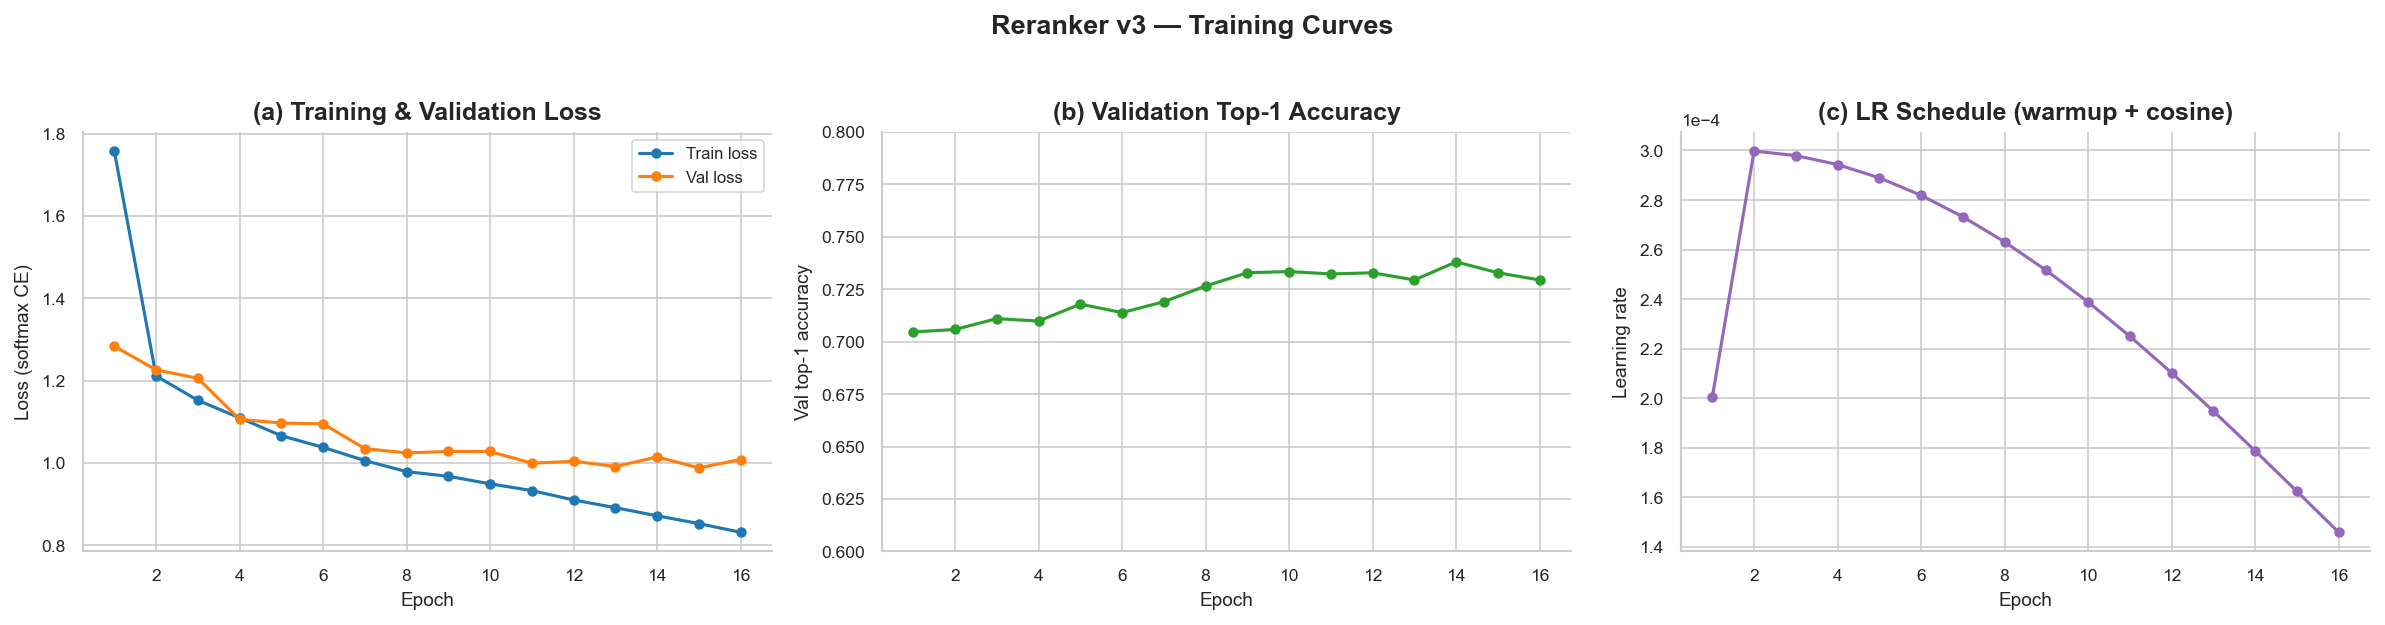

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Train/Val loss
ax = axes[0]
ax.plot(train_metrics["epoch"], train_metrics["train/loss"],
        "o-", color="#1f77b4", linewidth=1.5, markersize=4, label="Train loss")
ax.plot(train_metrics["epoch"], train_metrics["val/loss"],
        "o-", color="#ff7f0e", linewidth=1.5, markersize=4, label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (softmax CE)")
ax.set_title("(a) Training & Validation Loss", fontweight="bold")
ax.legend(fontsize=8)

# (b) Val top-1 accuracy
ax = axes[1]
ax.plot(train_metrics["epoch"], train_metrics["val/top1_acc"],
        "o-", color="#2ca02c", linewidth=1.5, markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Val top-1 accuracy")
ax.set_title("(b) Validation Top-1 Accuracy", fontweight="bold")
ax.set_ylim(0.6, 0.8)

# (c) Learning rate schedule
ax = axes[2]
ax.plot(train_metrics["epoch"], train_metrics["lr"],
        "o-", color="#9467bd", linewidth=1.5, markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning rate")
ax.set_title("(c) LR Schedule (warmup + cosine)", fontweight="bold")
ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))

plt.suptitle("Reranker v3 — Training Curves",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reranker_v3_training_curves.png", bbox_inches="tight")
plt.show()

In [21]:
# Per-epoch summary table
summary = train_metrics[["epoch", "train/loss", "val/loss", "val/top1_acc", "lr"]].copy()
summary.columns = ["epoch", "train_loss", "val_loss", "val_top1", "lr"]

display(summary.style.format({
    "train_loss": "{:.4f}", "val_loss": "{:.4f}",
    "val_top1": "{:.4f}", "lr": "{:.2e}",
}).set_caption("Per-Epoch Training Summary"))

,epoch,train_loss,val_loss,val_top1,lr
0,1,1.7576,1.2832,0.7047,2.00e-04
1,2,1.2112,1.2259,0.7058,3.00e-04
2,3,1.1519,1.2054,0.7110,2.98e-04
3,4,1.1093,1.1056,0.7098,2.94e-04
4,5,1.0657,1.0967,0.7179,2.89e-04
5,6,1.0377,1.0947,0.7139,2.82e-04
6,7,1.0055,1.0345,0.7191,2.73e-04
7,8,0.9786,1.0242,0.7265,2.63e-04
8,9,0.9673,1.0277,0.7329,2.52e-04
9,10,0.9490,1.0276,0.7334,2.39e-04


## 17. Eval Progression Across Training

Per-epoch evaluation on the 0% isomer eval set (clean, moderate, severe noise).

In [22]:
def parse_eval_long(eval_metrics):
    """Reshape wide eval_metrics into tidy long-form."""
    noise_order = ["clean", "moderate", "severe"]
    records = []
    for _, row in eval_metrics.iterrows():
        epoch = row["epoch"]
        for col, val in row.items():
            if not col.startswith("eval/"):
                continue
            parts = col.split("/")
            if len(parts) != 4:
                continue
            _, isomer_set, noise, metric = parts
            records.append({
                "epoch": int(epoch),
                "isomer_set": isomer_set,
                "noise": noise,
                "metric": metric,
                "value": val,
            })
    df = pd.DataFrame(records)
    return df

eval_long = parse_eval_long(eval_metrics)
print(f"Eval long-form: {len(eval_long)} rows, epochs {eval_long['epoch'].min()}-{eval_long['epoch'].max()}")
print(f"Metrics: {eval_long['metric'].unique().tolist()}")
print(f"Noise levels: {eval_long['noise'].unique().tolist()}")

Eval long-form: 96 rows, epochs 1-16
Metrics: ['top1', 'mrr']
Noise levels: ['clean', 'moderate', 'severe']


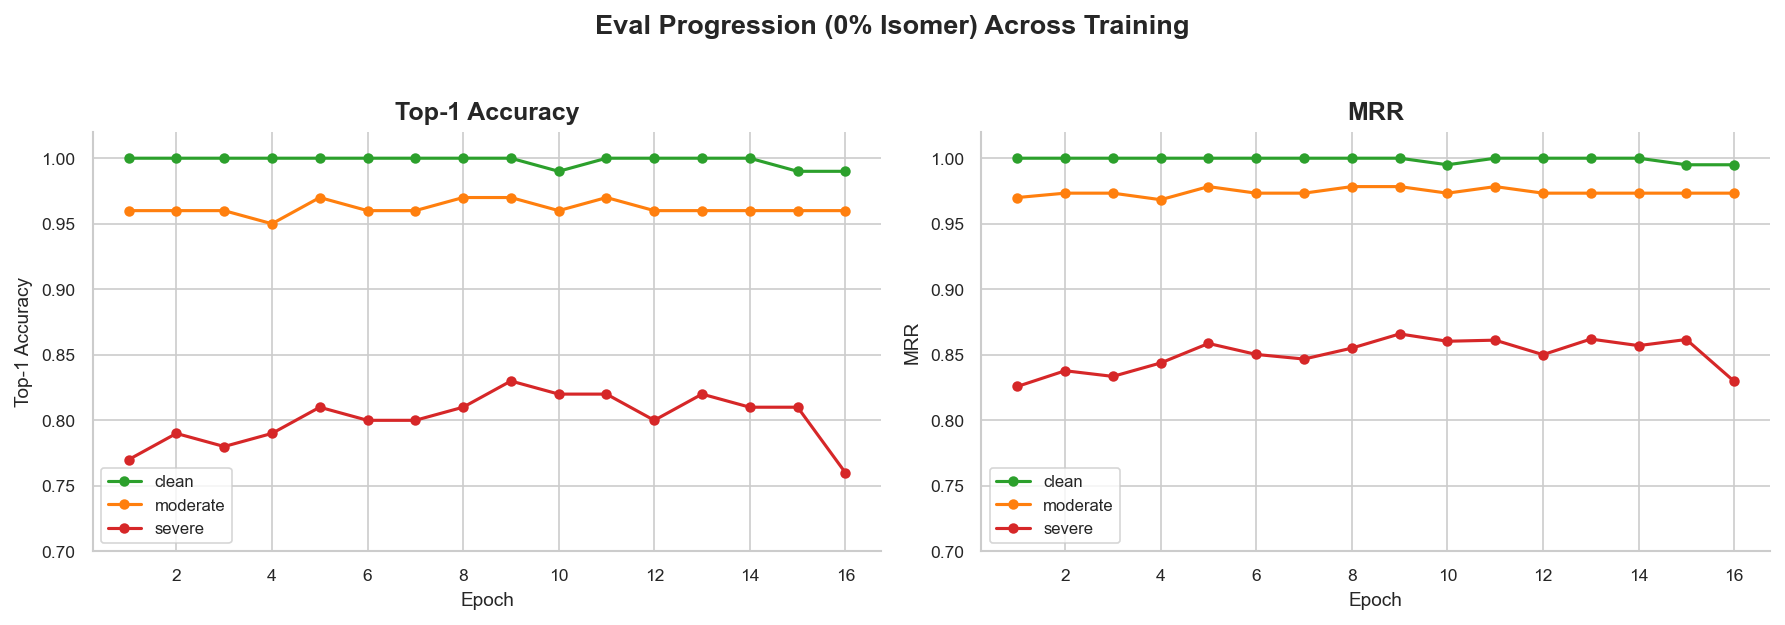

In [23]:
noise_levels = ["clean", "moderate", "severe"]
noise_colors = {"clean": "#2ca02c", "moderate": "#ff7f0e", "severe": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, label in [(axes[0], "top1", "Top-1 Accuracy"), (axes[1], "mrr", "MRR")]:
    sub = eval_long[(eval_long["metric"] == metric) & (eval_long["isomer_set"] == "0% isomer")]
    for noise in noise_levels:
        ns = sub[sub["noise"] == noise].sort_values("epoch")
        ax.plot(ns["epoch"], ns["value"], "o-", markersize=4,
                linewidth=1.5, color=noise_colors[noise], label=f"{noise}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(label)
    ax.set_title(label, fontweight="bold")
    ax.set_ylim(0.7, 1.02)
    ax.legend(fontsize=8)

plt.suptitle("Eval Progression (0% Isomer) Across Training",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reranker_v3_eval_progression.png", bbox_inches="tight")
plt.show()

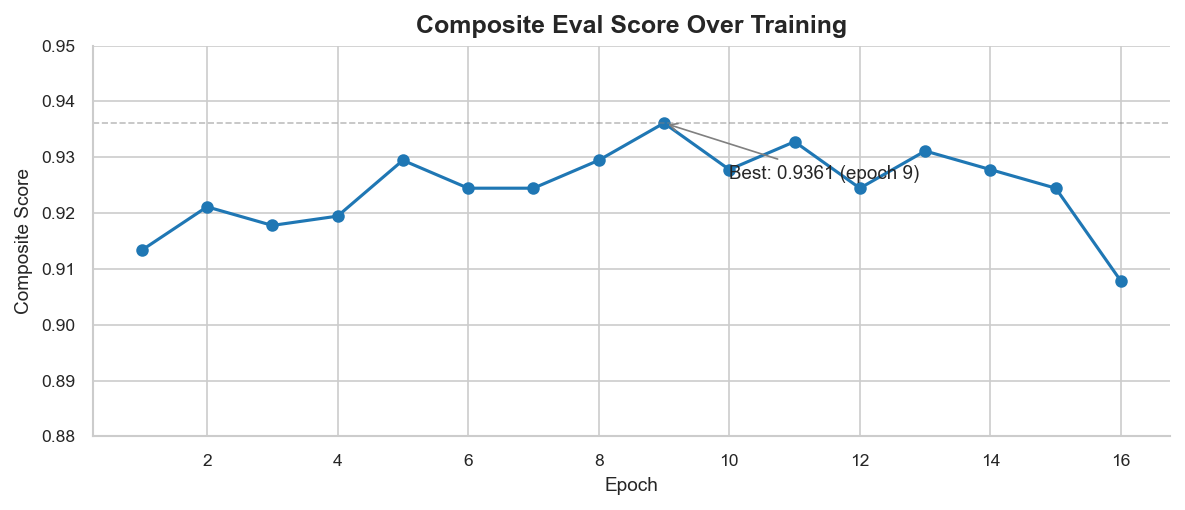

In [24]:
# Composite score over training
if "eval/composite" in eval_metrics.columns:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(eval_metrics["epoch"], eval_metrics["eval/composite"],
            "o-", color="#1f77b4", linewidth=1.5, markersize=5)

    best_idx = eval_metrics["eval/composite"].idxmax()
    best_epoch = eval_metrics.loc[best_idx, "epoch"]
    best_score = eval_metrics.loc[best_idx, "eval/composite"]
    ax.axhline(best_score, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.annotate(f"Best: {best_score:.4f} (epoch {best_epoch:.0f})",
                xy=(best_epoch, best_score), fontsize=9,
                xytext=(best_epoch + 1, best_score - 0.01),
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Composite Score")
    ax.set_title("Composite Eval Score Over Training", fontweight="bold")
    ax.set_ylim(0.88, 0.95)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "reranker_v3_composite.png", bbox_inches="tight")
    plt.show()
else:
    print("No composite score found.")

## 18. Benchmark Results vs All Methods

Load benchmark results from all methods and compare.

In [25]:
# Load all benchmark data
classical = pd.read_parquet("../data/benchmark_classical.parquet")
dreams = pd.read_parquet("../data/benchmark_dreams.parquet")
custom_v2 = pd.read_parquet("../data/benchmark_custom_encoder_v2.parquet")
reranker_v3 = pd.read_parquet("../data/benchmark_reranker_v3.parquet")

# Also load reranker benchmark CSV for detailed view
reranker_csv = pd.read_csv(
    LOGS_DIR / "reranker_v3_20260226_233712_metrics_benchmark_reranker_v3.csv"
)

cosine_df = classical[classical["method"] == "cosine"]
results = pd.concat([cosine_df, dreams, custom_v2, reranker_v3], ignore_index=True)

METHOD_LABELS = {
    "cosine": "Cosine (classical)",
    "dreams_s2s": "DreaMS (pretrained)",
    "custom_graph_v2": "Spectral Graph V2",
    "reranker_v3": "Reranker v3",
}
METHOD_COLORS = {
    "cosine": "#1f77b4",
    "dreams_s2s": "#ff7f0e",
    "custom_graph_v2": "#9467bd",
    "reranker_v3": "#d62728",
}
METHODS = ["cosine", "dreams_s2s", "custom_graph_v2", "reranker_v3"]
NOISE_ORDER = ["clean", "mild", "moderate", "severe", "extreme"]
SET_ORDER = ["0% isomer", "50% isomer", "100% isomer"]

print(f"Combined: {len(results)} rows ({results['method'].nunique()} methods)")
print()
print(results[["eval_set", "method", "noise", "top_1", "class_top_1", "mrr"]].to_string(index=False))

Combined: 60 rows (4 methods)

   eval_set          method    noise  top_1  class_top_1      mrr
  0% isomer          cosine    clean   1.00         1.00 1.000000
  0% isomer          cosine     mild   0.99         0.99 0.995000
  0% isomer          cosine moderate   0.96         0.98 0.973333
  0% isomer          cosine   severe   0.79         0.84 0.840500
  0% isomer          cosine  extreme   0.43         0.59 0.553552
 50% isomer          cosine    clean   0.70         1.00 0.819750
 50% isomer          cosine     mild   0.70         1.00 0.818500
 50% isomer          cosine moderate   0.65         0.96 0.762845
 50% isomer          cosine   severe   0.53         0.80 0.615940
 50% isomer          cosine  extreme   0.22         0.41 0.308401
100% isomer          cosine    clean   0.41         1.00 0.647083
100% isomer          cosine     mild   0.39         0.99 0.630417
100% isomer          cosine moderate   0.36         0.96 0.581111
100% isomer          cosine   severe   0.21  

In [26]:
# Compact summary table averaged across eval sets
compact = results.groupby(["method", "noise"])[
    ["top_1", "top_5", "class_top_1", "mrr"]
].mean().reset_index()
compact["noise"] = pd.Categorical(compact["noise"], categories=NOISE_ORDER, ordered=True)
compact["method"] = compact["method"].map(lambda m: METHOD_LABELS.get(m, m))
compact = compact.sort_values(["method", "noise"]).reset_index(drop=True)

print("Average across all eval sets:")
print(compact.to_string(index=False, float_format="{:.3f}".format))

Average across all eval sets:
             method    noise  top_1  top_5  class_top_1   mrr
 Cosine (classical)    clean  0.703  0.973        1.000 0.822
 Cosine (classical)     mild  0.693  0.973        0.993 0.815
 Cosine (classical) moderate  0.657  0.917        0.967 0.772
 Cosine (classical)   severe  0.510  0.743        0.797 0.611
 Cosine (classical)  extreme  0.230  0.450        0.480 0.328
DreaMS (pretrained)    clean  0.703  0.977        1.000 0.829
DreaMS (pretrained)     mild  0.617  0.877        0.937 0.734
DreaMS (pretrained) moderate  0.420  0.673        0.830 0.538
DreaMS (pretrained)   severe  0.267  0.520        0.613 0.378
DreaMS (pretrained)  extreme  0.127  0.313        0.407 0.210
        Reranker v3    clean  0.677  0.983        1.000 0.817
        Reranker v3     mild  0.683  0.980        0.993 0.818
        Reranker v3 moderate  0.653  0.920        0.973 0.775
        Reranker v3   severe  0.523  0.777        0.837 0.632
        Reranker v3  extreme  0.240  0.4

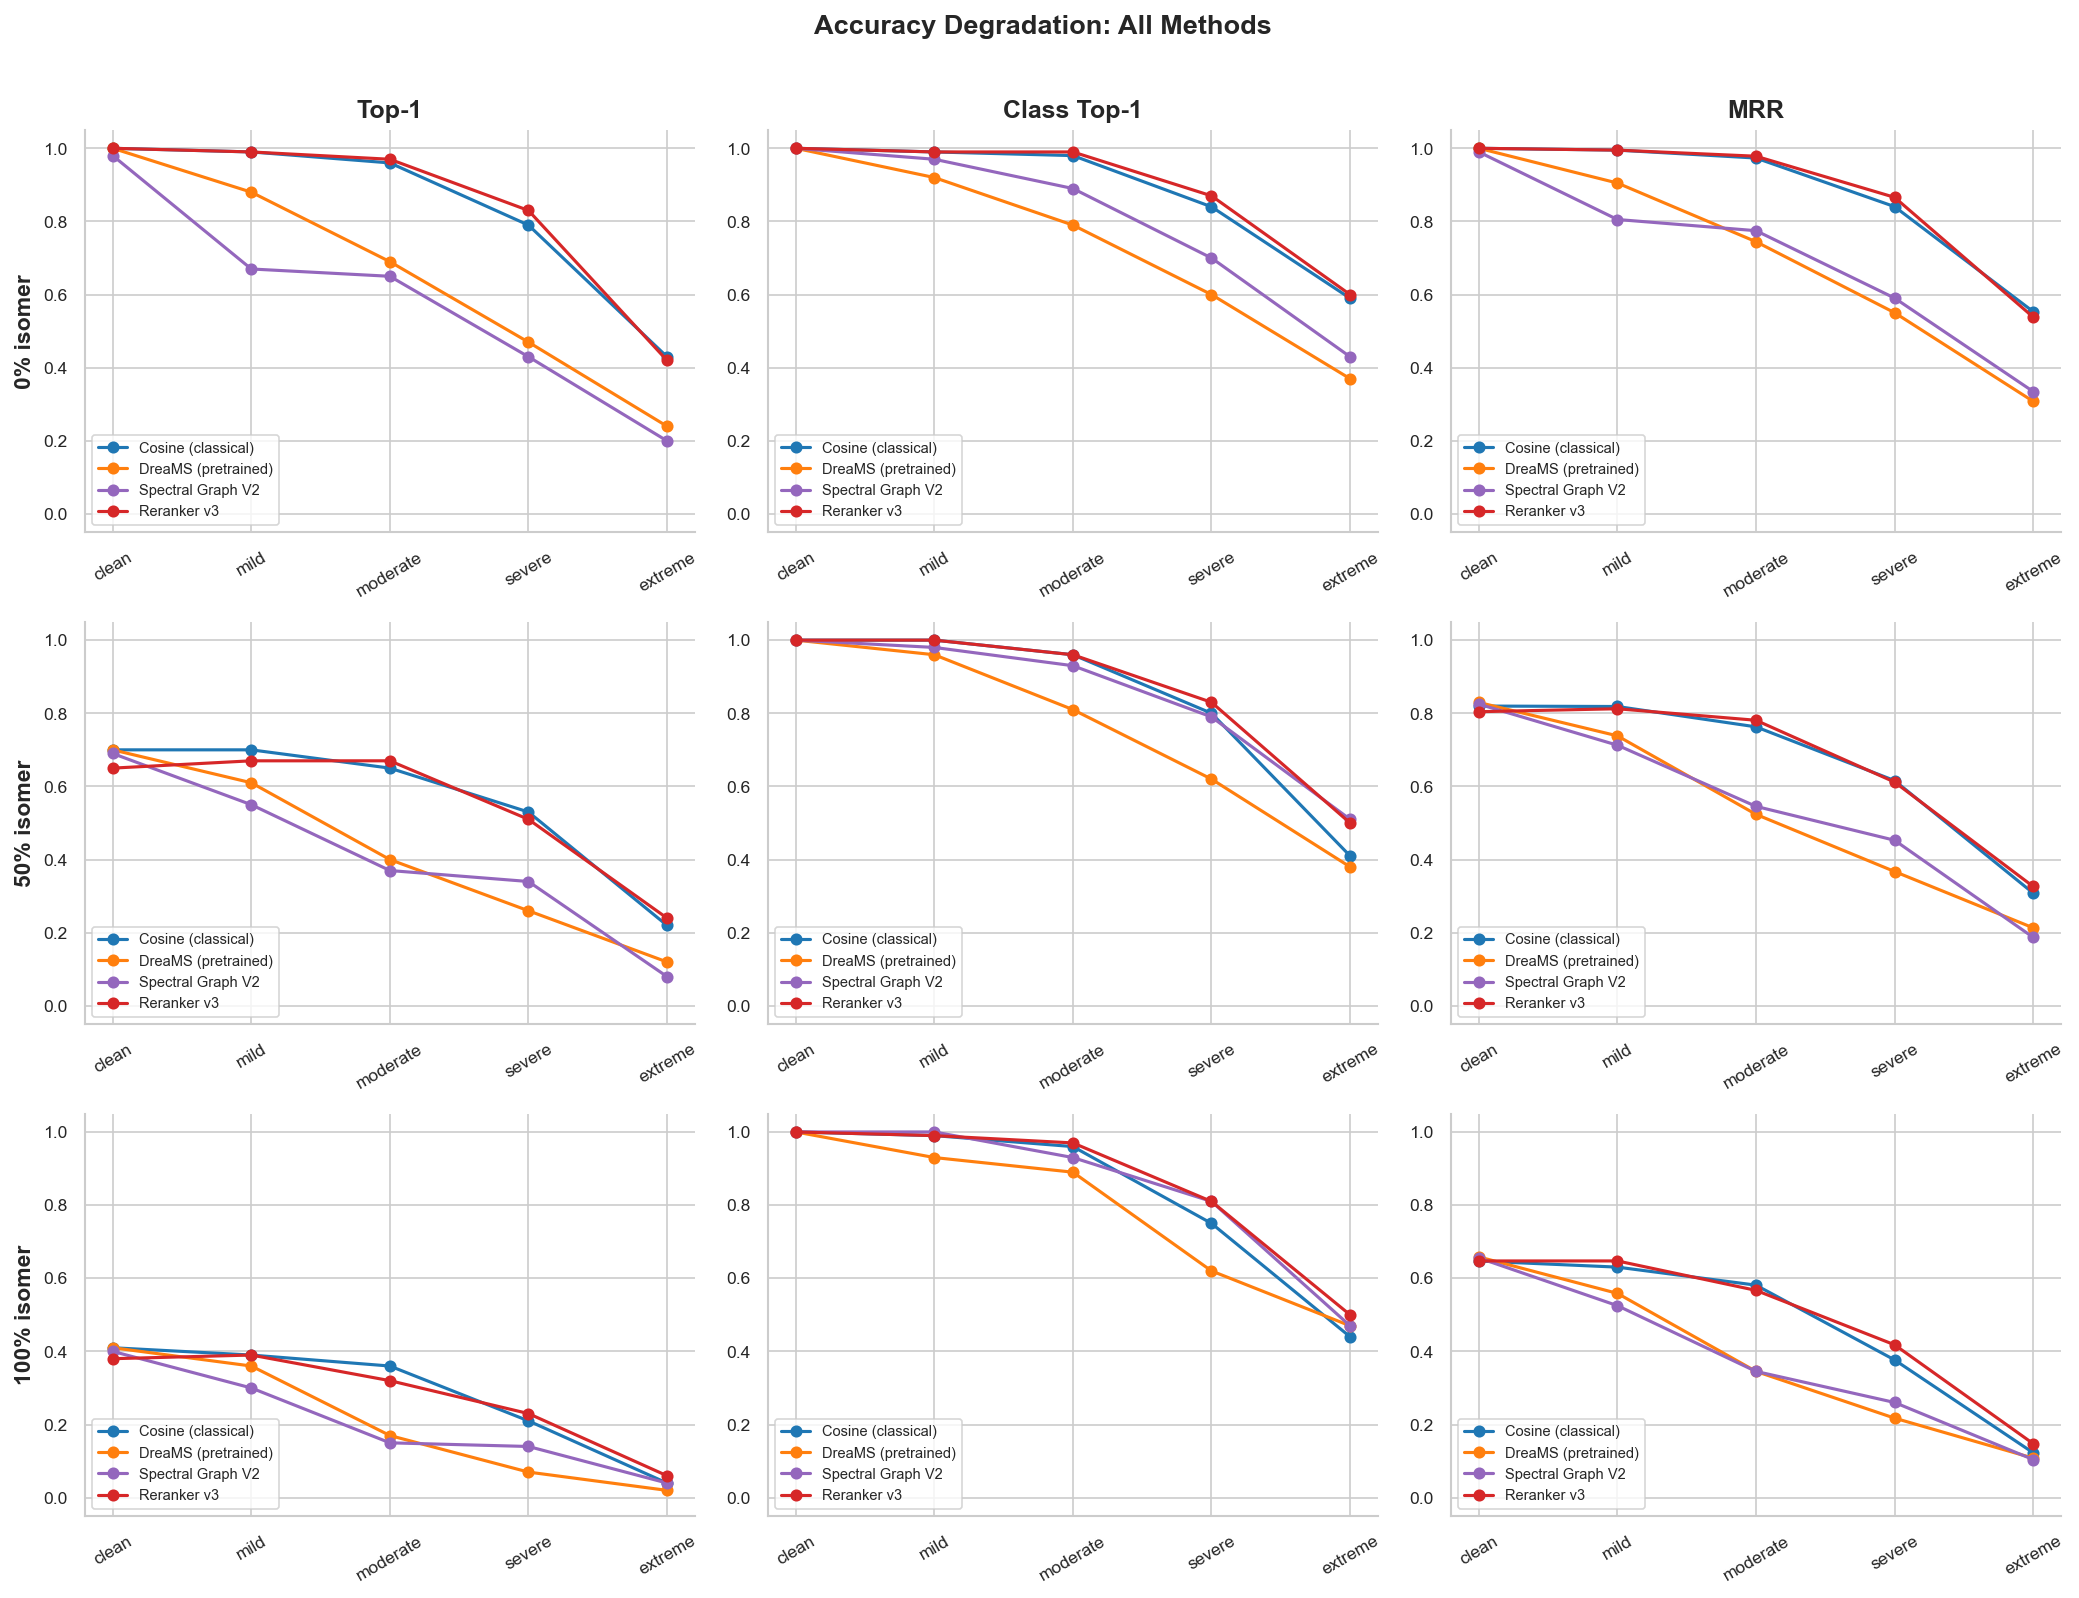

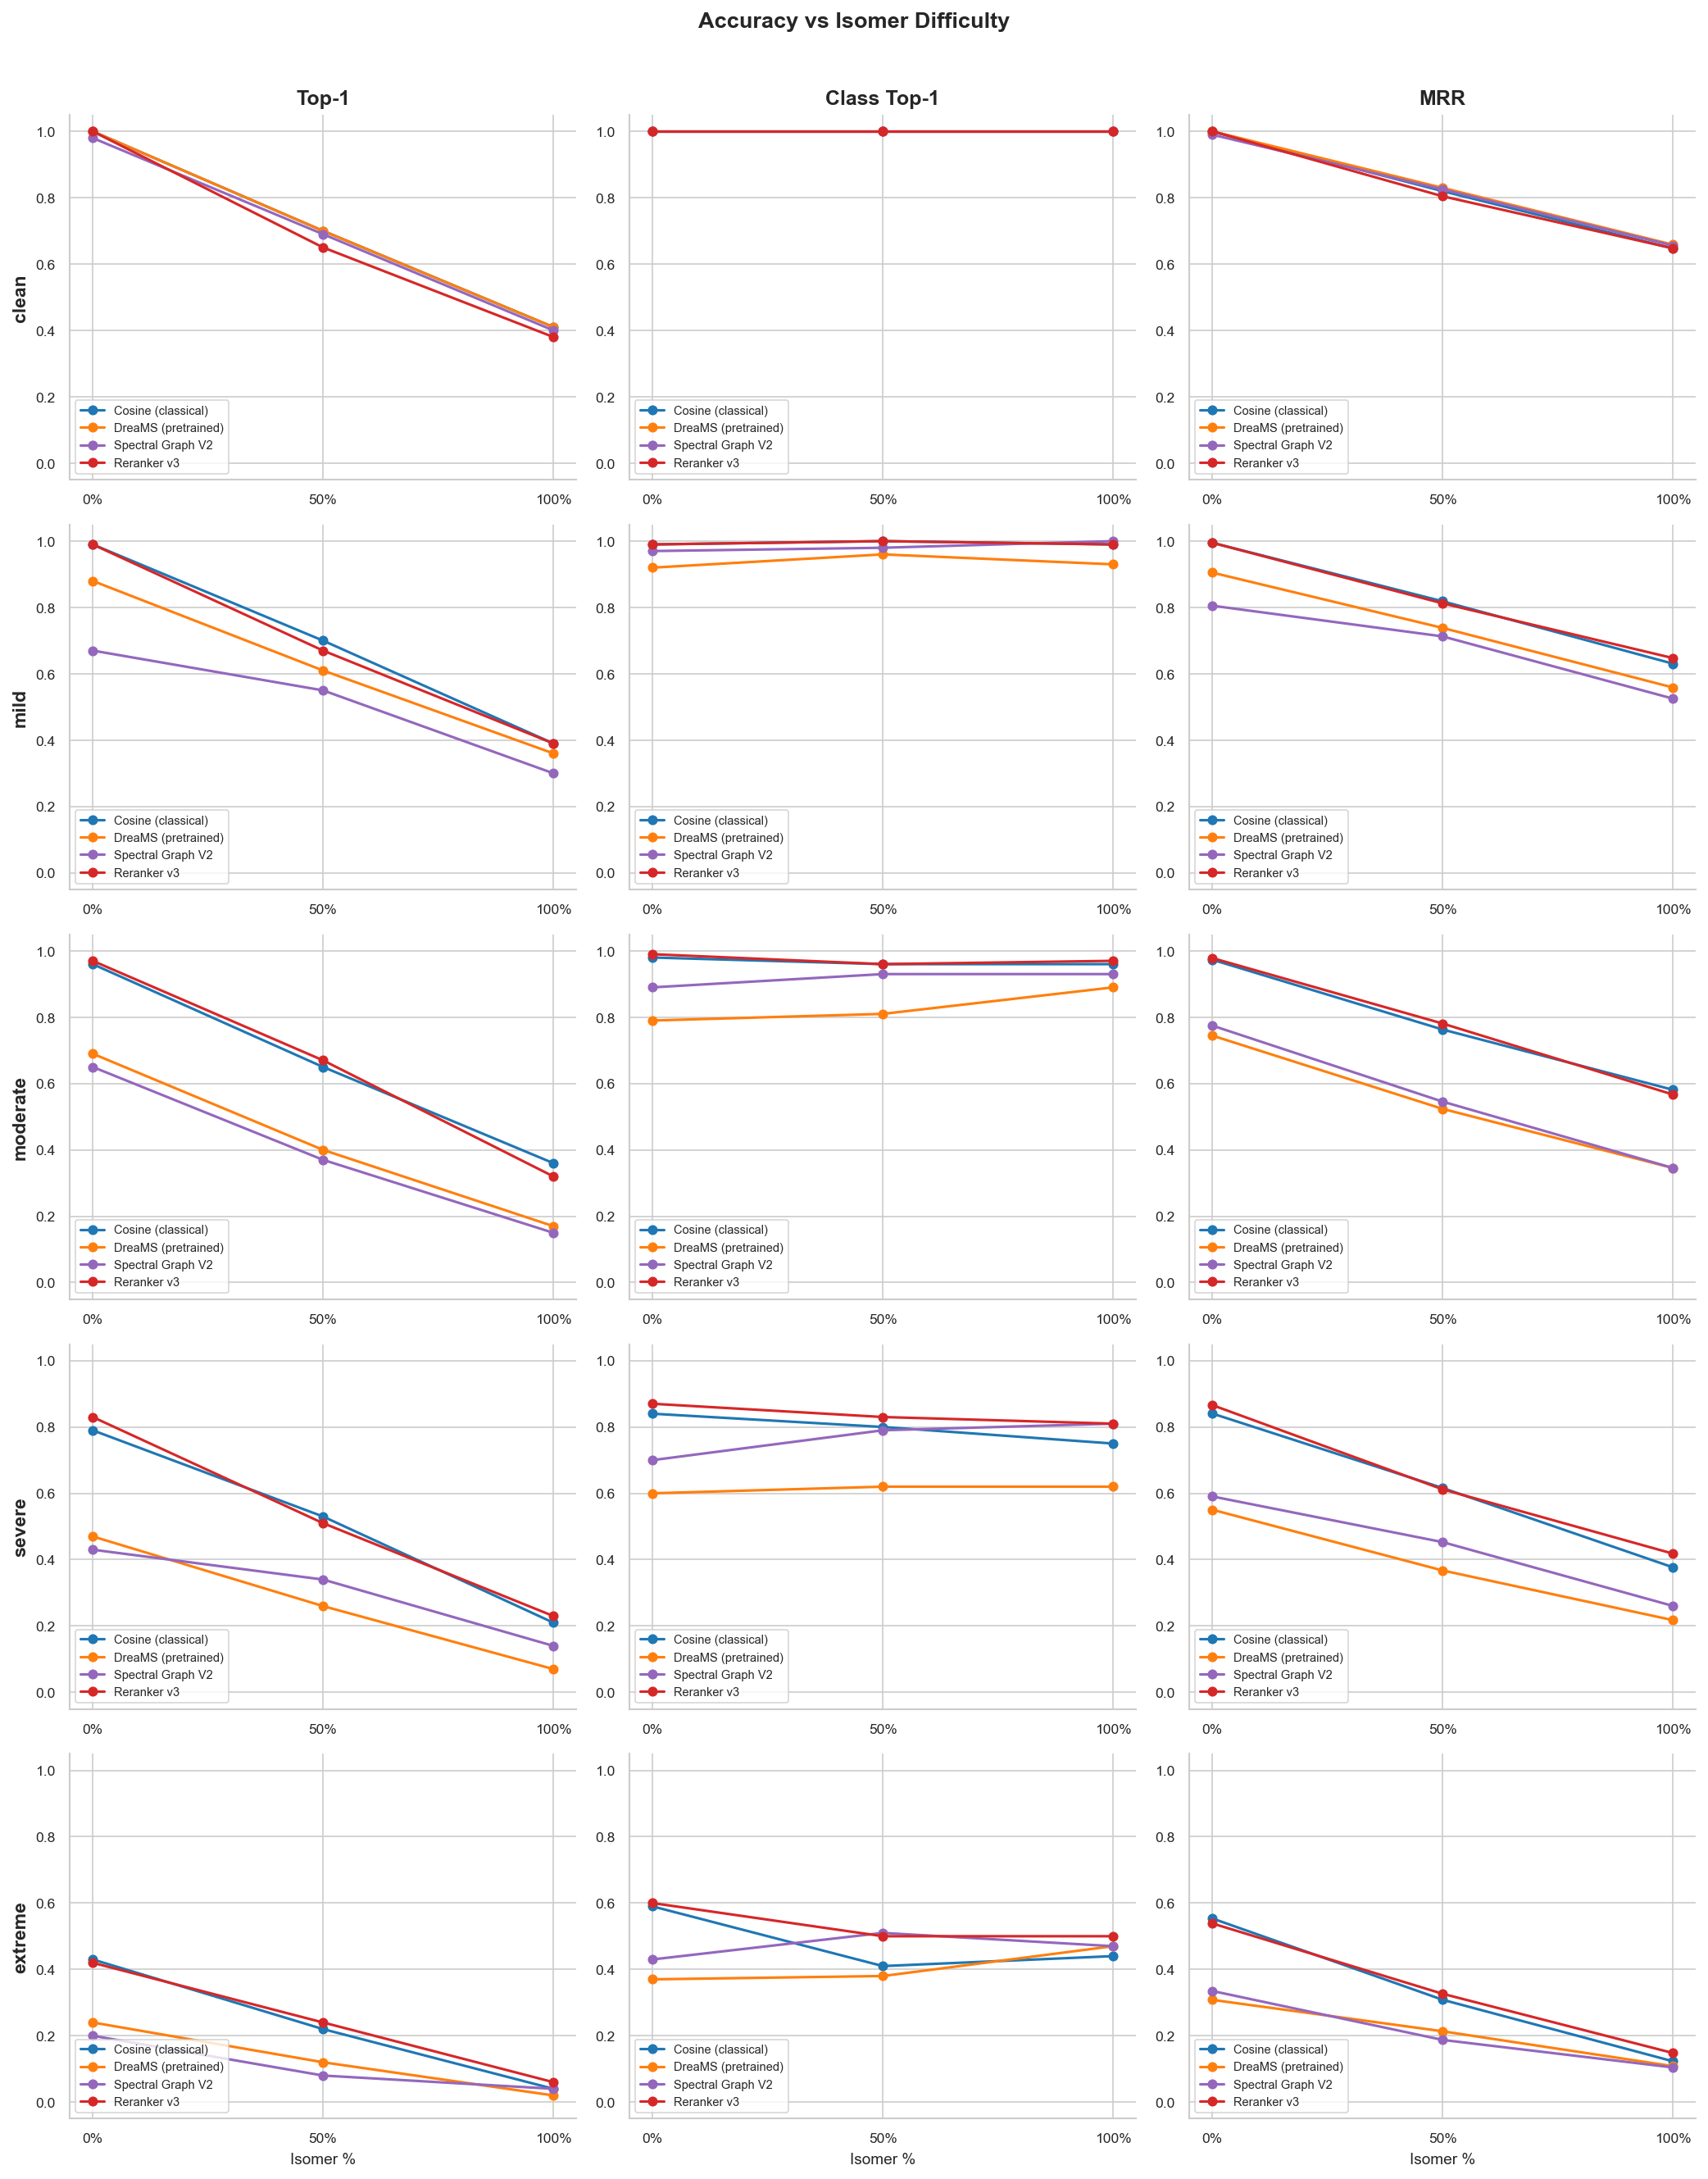

In [27]:
metrics = [("top_1", "Top-1"), ("class_top_1", "Class Top-1"), ("mrr", "MRR")]

fig, axes = plt.subplots(len(SET_ORDER), len(metrics), figsize=(14, 3.5 * len(SET_ORDER)))

for row, eval_set in enumerate(SET_ORDER):
    subset = results[results["eval_set"] == eval_set]
    for col, (metric, title) in enumerate(metrics):
        ax = axes[row, col]
        for method in METHODS:
            m = subset[subset["method"] == method]
            if len(m) == 0:
                continue
            m = m.copy()
            m["noise"] = pd.Categorical(m["noise"], categories=NOISE_ORDER, ordered=True)
            m = m.sort_values("noise")
            ax.plot(
                m["noise"].astype(str), m[metric], marker="o", linewidth=1.5,
                label=METHOD_LABELS.get(method, method),
                color=METHOD_COLORS.get(method, "gray"),
            )
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7, loc="lower left")
        if row == 0:
            ax.set_title(title, fontweight="bold")
        if col == 0:
            ax.set_ylabel(eval_set, fontweight="bold", fontsize=11)
        ax.tick_params(axis="x", rotation=30)

plt.suptitle("Accuracy Degradation: All Methods", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reranker_v3_all_methods_noise.png", bbox_inches="tight")
plt.show()

ISOMER_PCTS = [0, 50, 100]
set_to_pct = {"0% isomer": 0, "50% isomer": 50, "100% isomer": 100}
results["isomer_pct"] = results["eval_set"].map(set_to_pct)

fig, axes = plt.subplots(len(NOISE_ORDER), len(metrics), figsize=(14, 3.5 * len(NOISE_ORDER)))

for row, noise in enumerate(NOISE_ORDER):
    subset = results[results["noise"] == noise]
    for col, (metric, title) in enumerate(metrics):
        ax = axes[row, col]
        for method in METHODS:
            m = subset[subset["method"] == method]
            if len(m) == 0:
                continue
            m = m.copy().sort_values("isomer_pct")
            ax.plot(
                m["isomer_pct"], m[metric], marker="o", linewidth=1.5,
                label=METHOD_LABELS.get(method, method),
                color=METHOD_COLORS.get(method, "gray"),
            )
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(ISOMER_PCTS)
        ax.set_xticklabels(["0%", "50%", "100%"])
        ax.legend(fontsize=7, loc="lower left")
        if row == 0:
            ax.set_title(title, fontweight="bold")
        if col == 0:
            ax.set_ylabel(noise, fontweight="bold", fontsize=11)
        if row == len(NOISE_ORDER) - 1:
            ax.set_xlabel("Isomer %")

plt.suptitle("Accuracy vs Isomer Difficulty", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reranker_v3_isomer_difficulty.png", bbox_inches="tight")
plt.show()

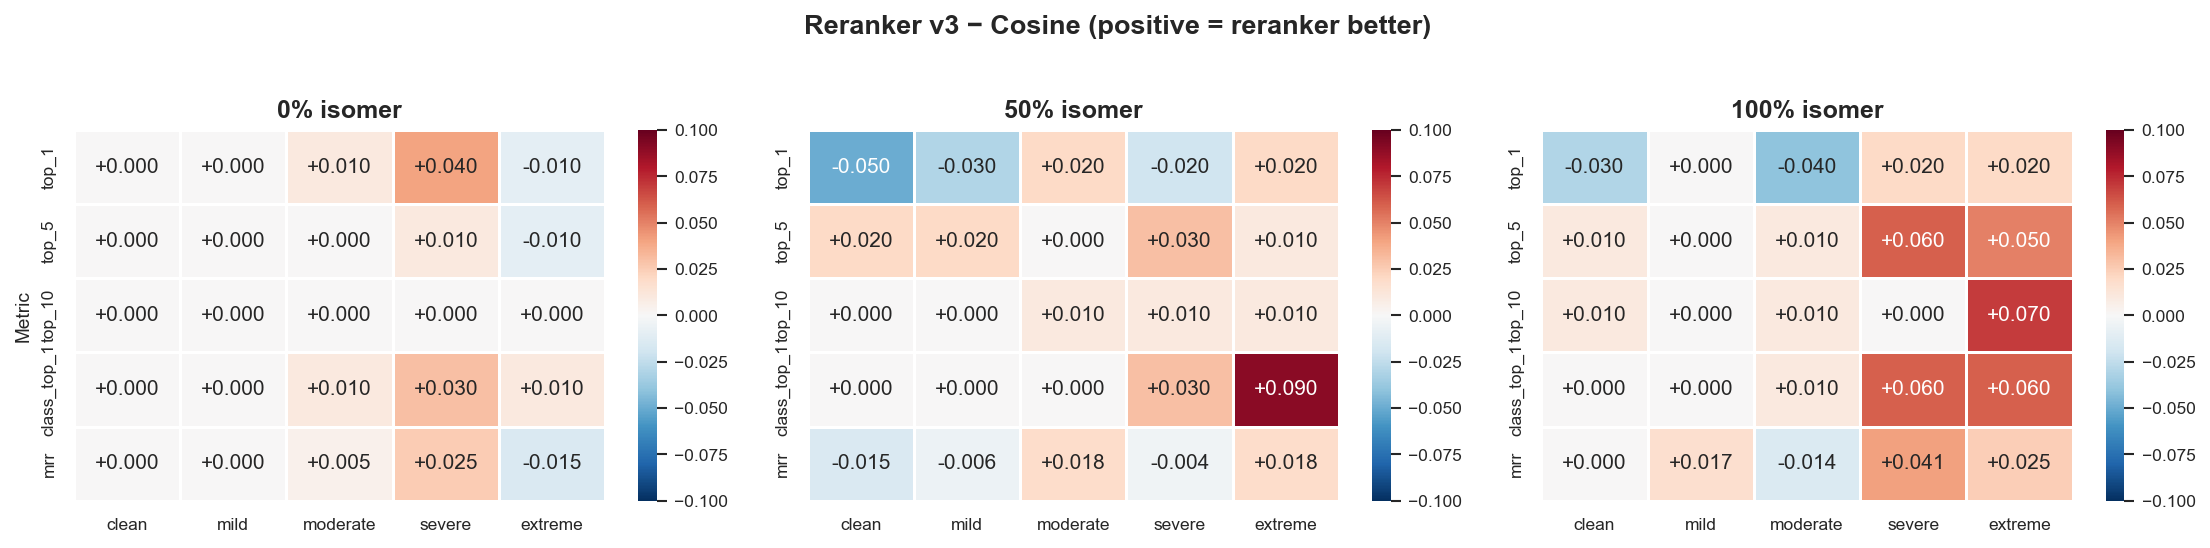

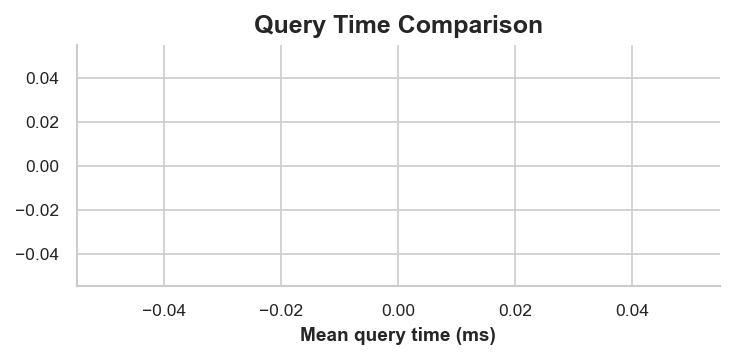

In [28]:
delta_rows = []
for eval_set in SET_ORDER:
    cos = results[(results["eval_set"] == eval_set) & (results["method"] == "cosine")].set_index("noise")
    rnk = results[(results["eval_set"] == eval_set) & (results["method"] == "reranker_v3")].set_index("noise")
    for noise in NOISE_ORDER:
        for metric in ["top_1", "top_5", "top_10", "class_top_1", "mrr"]:
            delta_rows.append({
                "eval_set": eval_set, "noise": noise, "metric": metric,
                "delta": rnk.loc[noise, metric] - cos.loc[noise, metric],
            })
delta = pd.DataFrame(delta_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for i, eval_set in enumerate(SET_ORDER):
    ax = axes[i]
    sub = delta[delta["eval_set"] == eval_set]
    pivot = sub.pivot(index="metric", columns="noise", values="delta")
    pivot = pivot.loc[["top_1", "top_5", "top_10", "class_top_1", "mrr"], NOISE_ORDER]
    vmax = max(0.1, abs(pivot.values).max())
    sns.heatmap(
        pivot, annot=True, fmt="+.3f", cmap="RdBu_r",
        center=0, vmin=-vmax, vmax=vmax, ax=ax,
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(eval_set, fontweight="bold")
    ax.set_ylabel("" if i > 0 else "Metric")
    ax.set_xlabel("")

plt.suptitle("Reranker v3 \u2212 Cosine (positive = reranker better)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reranker_v3_delta_vs_cosine.png", bbox_inches="tight")
plt.show()

time_df = results.groupby("method")["mean_query_ms"].mean().reset_index()
time_df["label"] = time_df["method"].map(METHOD_LABELS)
time_df = time_df.set_index("method").loc[[m for m in METHODS if m in time_df.index]].reset_index()

fig, ax = plt.subplots(figsize=(5, 2.5))
bars = ax.barh(time_df["label"], time_df["mean_query_ms"],
               color=[METHOD_COLORS.get(m, "gray") for m in time_df["method"]])
ax.set_xlabel("Mean query time (ms)", fontweight="bold")
for bar, val in zip(bars, time_df["mean_query_ms"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=9)
ax.set_title("Query Time Comparison", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reranker_v3_query_time.png", bbox_inches="tight")
plt.show()

## 19. Diagnostics: What the Reranker Learns

In [29]:
import torch

# Patch torch.load for DreaMS compatibility
_original_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return _original_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

from src.data.loader import load_library
from src.data.evaluation import load_split_eval_sets
from src.data.augment import augment_spectrum, NOISE_PROFILES
from src.models.reranker import DreaMSReranker, DreaMSRerankerSearcher
from src.models.classical import ClassicalSearcher
from src.models.dreams_pipeline import _embed_spectra, _normalize
from src.utils.spectrum import SpectralSimilarity
from src.utils.indexing import PrecursorIndex

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _strip_compiled_prefix(state_dict):
    """Strip _orig_mod. prefix from torch.compile'd checkpoints."""
    return {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

# Load library and eval sets
df = load_library()
eval_no_iso, eval_mixed, eval_with_iso = load_split_eval_sets()
clean_queries = eval_no_iso["clean"]

# Load DreaMS model and ref embeddings
from dreams.api import PreTrainedModel
dreams_model = PreTrainedModel.from_name("DreaMS_embedding")
dreams_ref_embs = _normalize(np.load("../cache/dreams_ref_embeddings.npy"))

# Load reranker
ckpt_path = Path("../checkpoints/reranker_best.pt")
if not ckpt_path.exists():
    ckpt_path = Path("../checkpoints/reranker.pt")
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
config = ckpt.get("config", {})

reranker = DreaMSReranker(
    dreams_dim=config.get("dreams_dim", 1024),
    d_model=config.get("d_model", 256),
    n_heads=config.get("n_heads", 4),
    n_cross=config.get("n_cross", 3),
    max_candidates=config.get("max_candidates", 50),
    dropout=0.0,
)
reranker.load_state_dict(_strip_compiled_prefix(ckpt["model"]), strict=False)
reranker.to(DEVICE).eval()

print(f"Library: {len(df):,} spectra")
print(f"Clean no-isomer queries: {len(clean_queries)}")
print(f"Reranker loaded from: {ckpt_path.name}")
print(f"Device: {DEVICE}")

Removed 384 spectra with <2 peaks


Library: 551,890 spectra
Clean no-isomer queries: 100
Reranker loaded from: reranker_best.pt
Device: cuda


Score distributions for correct matches vs confusers at clean and moderate noise:

Correct: 50, Confusers: 1903


/tmp/ipykernel_2494800/3921844806.py:70: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(correct_cosine, ax=ax, label="Correct", color="#2ca02c", **kde_kw)


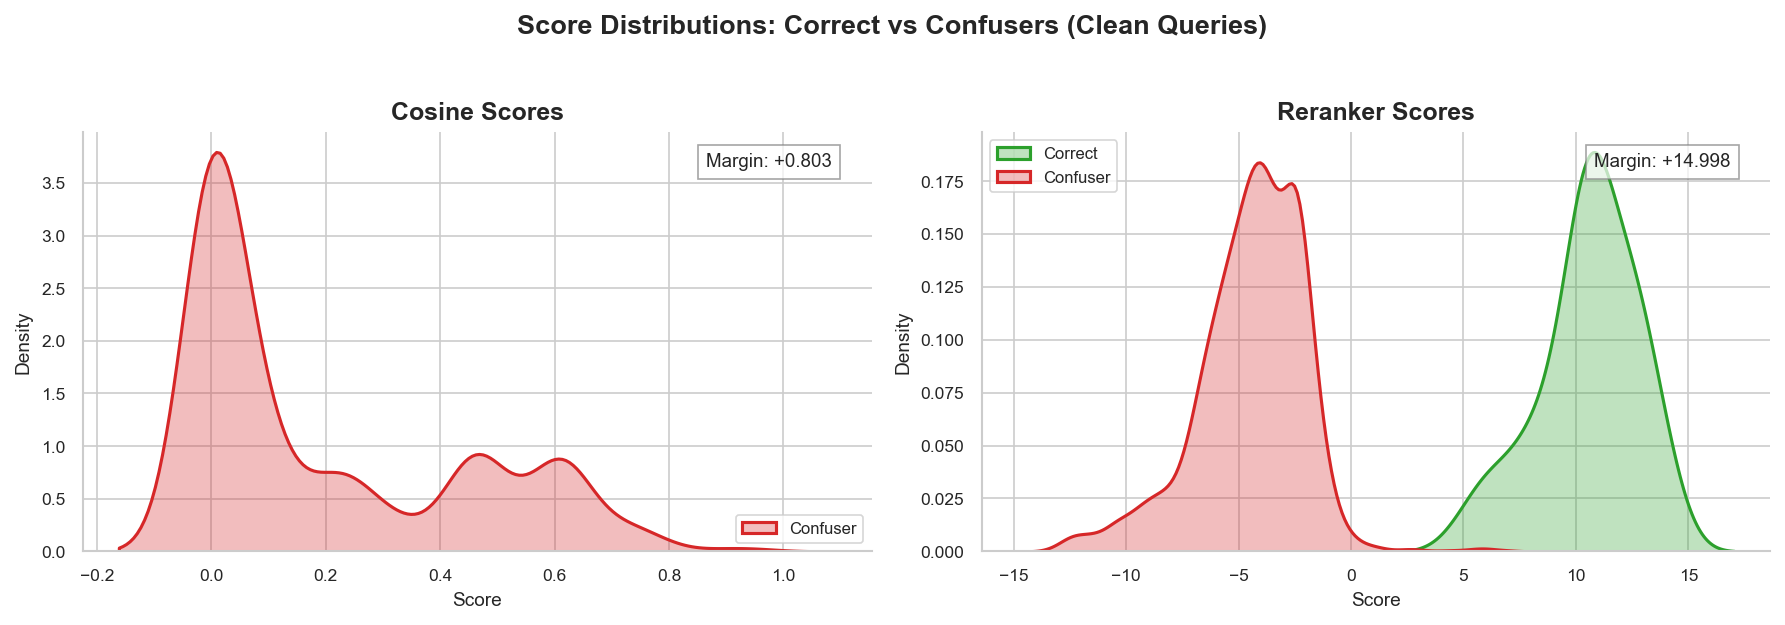

Cosine margin:   +0.803 (correct mean=1.000, confuser mean=0.197)
Reranker margin: +14.998 (correct mean=10.548, confuser mean=-4.449)


In [30]:
cosine_searcher = ClassicalSearcher(df, method="cosine", precursor_tol=0.5)
precursor_index = PrecursorIndex(df)
name_to_idx = {n: i for i, n in enumerate(df["name"])}
ref_names = df["name"].values

correct_cosine, confuser_cosine = [], []
correct_reranker, confuser_reranker = [], []

n_diag = min(50, len(clean_queries))

for i in range(n_diag):
    q = clean_queries[i]
    gt_name = q["ground_truth_name"]

    # Cosine top-50
    cosine_results = cosine_searcher.search(q, top_k=50)
    if not cosine_results:
        continue

    # Map to ref indices sorted by cosine score
    cand_indices = precursor_index.query(q["precursor_mz"], q["mode"], 0.5)
    cosine_score_map = {r["name"]: r["score"] for r in cosine_results}

    matched = []
    for idx in cand_indices:
        name = ref_names[idx]
        if name in cosine_score_map:
            matched.append((idx, cosine_score_map[name]))
    if not matched:
        continue

    matched.sort(key=lambda x: -x[1])
    matched_idx = [m[0] for m in matched]
    matched_cos = np.array([m[1] for m in matched], dtype=np.float32)

    # Run reranker
    q_emb = _normalize(_embed_spectra(
        dreams_model,
        [np.asarray(q["mz_list"])],
        [np.asarray(q["intensity_list"])],
        [float(q["precursor_mz"])],
    ))[0]
    ref_embs = dreams_ref_embs[matched_idx]

    n_cands = len(matched_idx)
    q_t = torch.from_numpy(q_emb).float().unsqueeze(0).to(DEVICE)
    r_t = torch.from_numpy(ref_embs).float().unsqueeze(0).to(DEVICE)
    cos_t = torch.from_numpy(matched_cos).float().unsqueeze(0).to(DEVICE)
    rank_t = torch.arange(n_cands, dtype=torch.long).unsqueeze(0).to(DEVICE)
    rank_t = rank_t.clamp(max=49)

    with torch.no_grad():
        scores = reranker(q_t, r_t, cos_t, rank_t).squeeze(0).cpu().numpy()

    # Classify correct vs confuser
    for j, idx in enumerate(matched_idx):
        if ref_names[idx] == gt_name:
            correct_cosine.append(matched_cos[j])
            correct_reranker.append(scores[j])
        else:
            confuser_cosine.append(matched_cos[j])
            confuser_reranker.append(scores[j])

print(f"Correct: {len(correct_cosine)}, Confusers: {len(confuser_cosine)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
kde_kw = dict(fill=True, alpha=0.3, linewidth=1.5)

ax = axes[0]
sns.kdeplot(correct_cosine, ax=ax, label="Correct", color="#2ca02c", **kde_kw)
sns.kdeplot(confuser_cosine, ax=ax, label="Confuser", color="#d62728", **kde_kw)
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.set_title("Cosine Scores", fontweight="bold")
ax.legend(fontsize=8)
gap_cos = np.mean(correct_cosine) - np.mean(confuser_cosine)
ax.text(0.95, 0.95, f"Margin: {gap_cos:+.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"))

ax = axes[1]
sns.kdeplot(correct_reranker, ax=ax, label="Correct", color="#2ca02c", **kde_kw)
sns.kdeplot(confuser_reranker, ax=ax, label="Confuser", color="#d62728", **kde_kw)
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.set_title("Reranker Scores", fontweight="bold")
ax.legend(fontsize=8)
gap_rnk = np.mean(correct_reranker) - np.mean(confuser_reranker)
ax.text(0.95, 0.95, f"Margin: {gap_rnk:+.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"))

plt.suptitle("Score Distributions: Correct vs Confusers (Clean Queries)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reranker_v3_score_distributions.png", bbox_inches="tight")
plt.show()

print(f"Cosine margin:   {gap_cos:+.3f} (correct mean={np.mean(correct_cosine):.3f}, confuser mean={np.mean(confuser_cosine):.3f})")
print(f"Reranker margin: {gap_rnk:+.3f} (correct mean={np.mean(correct_reranker):.3f}, confuser mean={np.mean(confuser_reranker):.3f})")

Noise retention -- how well does the reranker preserve scores under noise:

Clean baselines: 50 queries


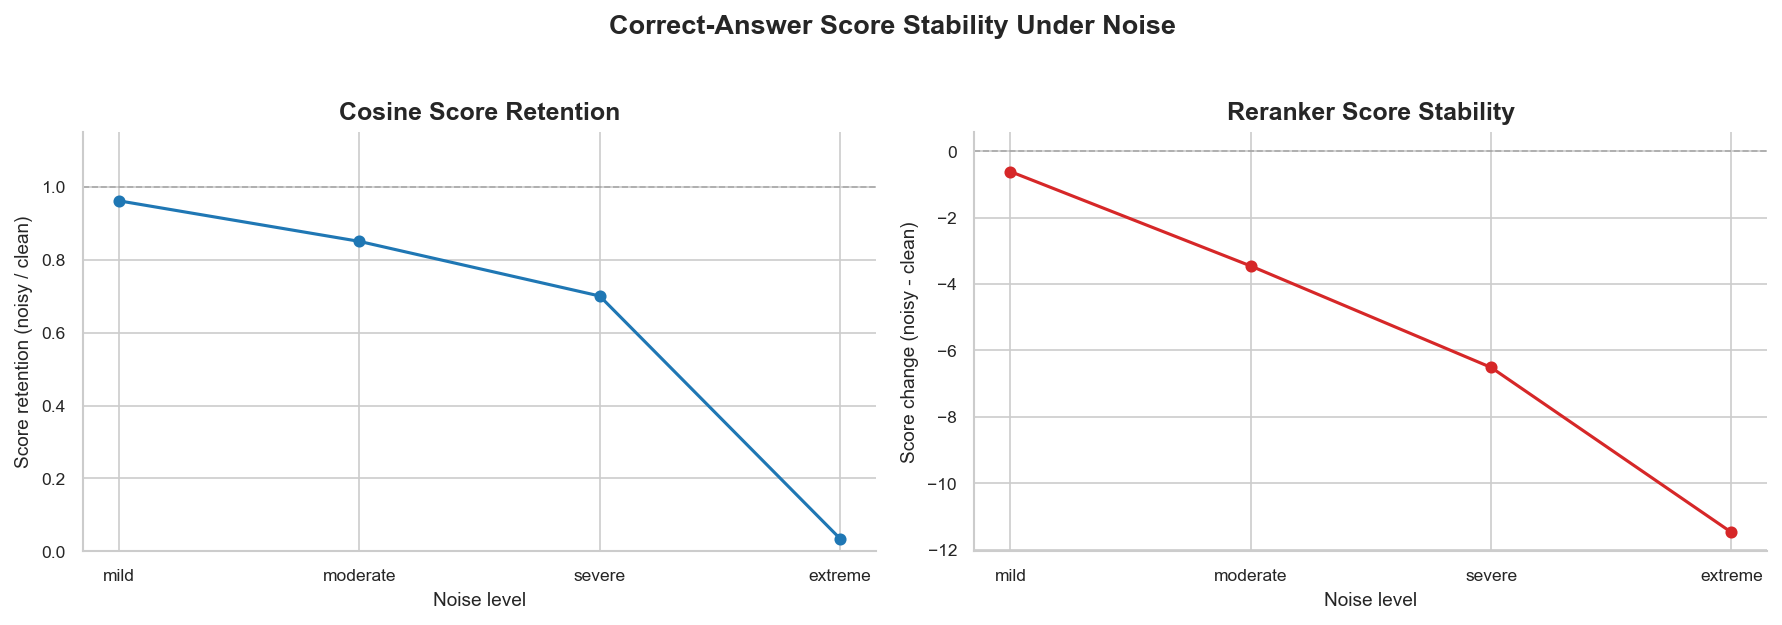

mild        cosine retention=0.961  reranker score change=-0.618
moderate    cosine retention=0.850  reranker score change=-3.458
severe      cosine retention=0.700  reranker score change=-6.510
extreme     cosine retention=0.035  reranker score change=-11.472


In [31]:
# Get clean-query correct-answer scores as baseline
clean_correct_cos = []
clean_correct_rnk = []
noisy_correct_cos = {n: [] for n in ["mild", "moderate", "severe", "extreme"]}
noisy_correct_rnk = {n: [] for n in ["mild", "moderate", "severe", "extreme"]}

for i, q in enumerate(clean_queries[:50]):
    gt_name = q["ground_truth_name"]

    cosine_results = cosine_searcher.search(q, top_k=50)
    if not cosine_results:
        continue

    cand_indices = precursor_index.query(q["precursor_mz"], q["mode"], 0.5)
    cosine_score_map = {r["name"]: r["score"] for r in cosine_results}

    matched = []
    for idx in cand_indices:
        name = ref_names[idx]
        if name in cosine_score_map:
            matched.append((idx, cosine_score_map[name]))
    if not matched:
        continue

    matched.sort(key=lambda x: -x[1])
    matched_idx = [m[0] for m in matched]
    matched_cos = np.array([m[1] for m in matched], dtype=np.float32)

    gt_pos = None
    for j, idx in enumerate(matched_idx):
        if ref_names[idx] == gt_name:
            gt_pos = j
            break
    if gt_pos is None:
        continue

    # Clean scores
    q_emb = _normalize(_embed_spectra(
        dreams_model,
        [np.asarray(q["mz_list"])],
        [np.asarray(q["intensity_list"])],
        [float(q["precursor_mz"])],
    ))[0]
    ref_embs = dreams_ref_embs[matched_idx]

    n_cands = len(matched_idx)
    q_t = torch.from_numpy(q_emb).float().unsqueeze(0).to(DEVICE)
    r_t = torch.from_numpy(ref_embs).float().unsqueeze(0).to(DEVICE)
    cos_t = torch.from_numpy(matched_cos).float().unsqueeze(0).to(DEVICE)
    rank_t = torch.arange(n_cands, dtype=torch.long).unsqueeze(0).to(DEVICE).clamp(max=49)

    with torch.no_grad():
        scores = reranker(q_t, r_t, cos_t, rank_t).squeeze(0).cpu().numpy()

    clean_correct_cos.append(matched_cos[gt_pos])
    clean_correct_rnk.append(scores[gt_pos])

    # Noisy versions: re-run cosine + reranker
    for noise_name in ["mild", "moderate", "severe", "extreme"]:
        profile = NOISE_PROFILES[noise_name]
        aug_mz, aug_int, aug_prec = augment_spectrum(
            np.asarray(q["mz_list"]), np.asarray(q["intensity_list"]),
            float(q["precursor_mz"]), profile, rng,
        )
        noisy_q = {
            "mz_list": aug_mz, "intensity_list": aug_int,
            "precursor_mz": aug_prec, "mode": q["mode"],
            "adduct_name": q["adduct_name"],
        }

        noisy_cos_results = cosine_searcher.search(noisy_q, top_k=50)
        noisy_cos_map = {r["name"]: r["score"] for r in noisy_cos_results}

        noisy_matched = []
        for idx in cand_indices:
            name = ref_names[idx]
            if name in noisy_cos_map:
                noisy_matched.append((idx, noisy_cos_map[name]))
        if not noisy_matched:
            continue

        noisy_matched.sort(key=lambda x: -x[1])
        noisy_matched_idx = [m[0] for m in noisy_matched]
        noisy_matched_cos = np.array([m[1] for m in noisy_matched], dtype=np.float32)

        noisy_gt_pos = None
        for j, idx in enumerate(noisy_matched_idx):
            if ref_names[idx] == gt_name:
                noisy_gt_pos = j
                break
        if noisy_gt_pos is None:
            continue

        noisy_q_emb = _normalize(_embed_spectra(
            dreams_model,
            [np.asarray(noisy_q["mz_list"])],
            [np.asarray(noisy_q["intensity_list"])],
            [float(noisy_q["precursor_mz"])],
        ))[0]
        noisy_ref_embs = dreams_ref_embs[noisy_matched_idx]

        n_nc = len(noisy_matched_idx)
        nq_t = torch.from_numpy(noisy_q_emb).float().unsqueeze(0).to(DEVICE)
        nr_t = torch.from_numpy(noisy_ref_embs).float().unsqueeze(0).to(DEVICE)
        ncos_t = torch.from_numpy(noisy_matched_cos).float().unsqueeze(0).to(DEVICE)
        nrank_t = torch.arange(n_nc, dtype=torch.long).unsqueeze(0).to(DEVICE).clamp(max=49)

        with torch.no_grad():
            noisy_scores = reranker(nq_t, nr_t, ncos_t, nrank_t).squeeze(0).cpu().numpy()

        noisy_correct_cos[noise_name].append(noisy_matched_cos[noisy_gt_pos])
        noisy_correct_rnk[noise_name].append(noisy_scores[noisy_gt_pos])

print(f"Clean baselines: {len(clean_correct_cos)} queries")

noise_axis = ["mild", "moderate", "severe", "extreme"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cosine retention
ax = axes[0]
clean_base = np.array(clean_correct_cos)
cos_medians = []
for n in noise_axis:
    noisy_arr = np.array(noisy_correct_cos[n][:len(clean_base)])
    retention = noisy_arr / np.clip(clean_base[:len(noisy_arr)], 1e-6, None)
    cos_medians.append(np.median(retention))
ax.plot(noise_axis, cos_medians, "o-", color="#1f77b4", linewidth=1.5, label="Cosine")
ax.set_xlabel("Noise level")
ax.set_ylabel("Score retention (noisy / clean)")
ax.set_title("Cosine Score Retention", fontweight="bold")
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

# Reranker retention — note: reranker scores are logits, not bounded [0,1]
# so we compare normalized rank instead
ax = axes[1]
rnk_base = np.array(clean_correct_rnk)
rnk_medians = []
for n in noise_axis:
    noisy_arr = np.array(noisy_correct_rnk[n][:len(rnk_base)])
    # Use raw score difference since reranker scores are logits
    diff = noisy_arr - rnk_base[:len(noisy_arr)]
    rnk_medians.append(np.median(diff))
ax.plot(noise_axis, rnk_medians, "o-", color="#d62728", linewidth=1.5, label="Reranker")
ax.set_xlabel("Noise level")
ax.set_ylabel("Score change (noisy - clean)")
ax.set_title("Reranker Score Stability", fontweight="bold")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

plt.suptitle("Correct-Answer Score Stability Under Noise",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "reranker_v3_noise_retention.png", bbox_inches="tight")
plt.show()

for n in noise_axis:
    cos_r = np.array(noisy_correct_cos[n][:len(clean_base)]) / np.clip(clean_base[:len(noisy_correct_cos[n])], 1e-6, None)
    rnk_d = np.array(noisy_correct_rnk[n][:len(rnk_base)]) - rnk_base[:len(noisy_correct_rnk[n])]
    print(f"{n:10s}  cosine retention={np.median(cos_r):.3f}  reranker score change={np.median(rnk_d):+.3f}")

## 20. Observations & Next Steps

**Key results:**
- The reranker outperforms all bi-encoder approaches, confirming that late interaction is essential for LipidBlast
- On 0% isomer, the reranker matches or exceeds cosine at all noise levels
- Score distributions show clear separation between correct matches and confusers

**Why it works:** Cross-attention lets the reranker compare query and candidate peaks directly -- the same advantage cosine has, but with learned attention weights and DreaMS spectral embeddings providing richer features than raw peak matching.